# Phase 1: Import Libraries and File Reading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install pingouin
import pingouin as pg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 3.6 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv("/content/Data300csv.csv")

# Find the index of the last desired column
last_col_name = '27. In the past month, have you  felt guilty or unable to stop blaming yourself or others for the event(s) or any problem that event(s) may have caused? \n၂၇။ လွန်ခဲ့သော တစ်လအတွင်း ဖြစ်ပျက်ခဲ့သော အဖြစ်အပျက်များ သို့မဟုတ် ထိုအဖြစ်အပျက်များကြောင့် ဖြစ်ပေါ်လာသော ပြဿနာများအတွက် သင့်ကိုယ်သင် သို့မဟုတ် အခြားသူများကို အပြစ်တင်နေခြင်း (သို့မဟုတ်) အပြစ်ရှိသလို ခံစားနေရခြင်းများ ရှိပါသလား။  '
last_col_index = df.columns.get_loc(last_col_name)

# Select columns from index 1 (to drop 'Timestamp') up to and including the last desired column
df = df.iloc[:, 1:last_col_index + 1]

# Phase 2: Data Preprocessing

In [ ]:
# Data Inspection
df.head()

,1.What is your Age? \n ၁။ သင့်အသက်မှာ မည်မျှရှိပါသလဲ။,2.What is your Gender? \n၂။ သင့်၏ လိင်အမျိုးအစားမှာ မည်သို့ရှိပါသလဲ။,3. What is your highest level of education? *\n၃။ သင့်၏ အမြင့်ဆုံး ပညာအရည်အချင်းမှာ မည်သို့ရှိပါသလဲ။,4. What is your current employment status? \n၄။ သင့်၏ လက်ရှိ အလုပ်အကိုင် အခြေအနေမှာ မည်သို့ရှိပါသလဲ။,5. What is your marital status? \n၅။ သင့်၏ အိမ်ထောင်ရေးအခြေအနေမှာ မည်သို့ရှိပါသလဲ။,"6. What is your approximate monthly household income? ( Please estimate the total income of all your family members, including yourself. This information is strictly confidential.) \n၆။ သင့်မိသားစု၏ တစ်လတာ စုစုပေါင်းဝင်ငွေမှာ ခန့်မှန်းခြေ မည်မျှရှိပါသလဲ။ (သင့်အပါအဝင် မိသားစုဝင်အားလုံး၏ ဝင်ငွေစုစုပေါင်းကို ခန့်မှန်းပေးပါ။ ဤအချက်အလက်များကို လျှို့ဝှက်ချက်အဖြစ်သာ တင်းကြပ်စွာ ထိန်းသိမ်းထားမည် ဖြစ်ပါသည်။)",7. What is your current residence status? \n၇။ လက်ရှိတွင် မည်ကဲ့သို့သော အခြေအနေဖြင့် နေထိုင်နေပါသလဲ။,8. Which State or Region are you currently living in? \n၈။ လက်ရှိတွင် မည်သည့် ပြည်နယ် သို့မဟုတ် တိုင်းဒေသကြီး၌ နေထိုင်နေပါသလဲ။,"9. If migrated, which country are you currently living in ? ၉။ အကယ်၍ ပြည်ပသို့ ရွှေ့ပြောင်းနေထိုင်သူဖြစ်ပါက လက်ရှိတွင် မည်သည့်နိုင်ငံ၌ နေထိုင်နေပါသလဲ။",10. How would you describe your living area? \n၁၀။ သင့်၏ နေထိုင်ရာဒေသ (သို့မဟုတ်) ပတ်ဝန်းကျင်ကို မည်သို့ ဖော်ပြလိုပါသလဲ။,...,"18. How easy is it for you to access essential services (e.g., food supplies, transportation, electricity, water, internet)? \n၁၈။ အခြေခံဝန်ဆောင်မှုများ (ဥပမာ - စားနပ်ရိက္ခာ၊ သွားလာရေး၊ လျှပ်စစ်မီး၊ ရေ နှင့် အင်တာနက်) ကို သင့်အနေဖြင့် မည်မျှအထိ လွယ်လွယ်ကူကူ ရရှိနိုင်ပါသလဲ။","19. Feeling Nervous, anxious or on edge? \n၁၉။ ဂနာမငြိမ်ဖြစ်ခြင်း၊ စိုးရိမ်ပူပန်ခြင်း သို့မဟုတ် စိတ်လှုပ်ရှားခြောက်ခြားခြင်းများ ခံစားရပါသလား။",20. Not being able to stop or control worrying? \n၂၀။ စိုးရိမ်ပူပန်မှုများကို မရပ်တန့်နိုင်ခြင်း သို့မဟုတ် မထိန်းချုပ်နိုင်ခြင်းများ ဖြစ်ပါသလား။,21. Little interest or pleasure in doing things? \n၂၁။ အလုပ်ကိစ္စများ သို့မဟုတ် ဝါသနာပါရာများကို လုပ်ဆောင်ရာတွင် စိတ်ပါဝင်စားမှု နည်းပါးခြင်း သို့မဟုတ် ပျော်ရွှင်မှုမရှိခြင်းတို့ ဖြစ်ပါသလား။,"22. Feeling down, depressed or hopeless? \n၂၂။ စိတ်ဓာတ်ကျခြင်း၊ စိတ်အားငယ်ခြင်း သို့မဟုတ် မျှော်လင့်ချက်မဲ့နေသကဲ့သို့ ခံစားရခြင်းများ ဖြစ်ပါသလား။","23. In the past month, have you had nightmares about the event(s) or thought about the event(s) when you did not want to ? \n၂၃။ လွန်ခဲ့သော တစ်လအတွင်း ဖြစ်ပျက်ခဲ့သော အဖြစ်အပျက်များနှင့် ပတ်သက်၍ အိပ်မက်ဆိုးများ မက်ခြင်း သို့မဟုတ် ထိုအဖြစ်အပျက်များကို မတွေးလိုသော်လည်း မကြာခဏ ပြန်လည်တွေးတောမိခြင်းများ ရှိပါသလား။","24. In the past month, have you tried hard not to think about the event(s) or went out of your way to avoid situations that remind you of the event(s)?\n၂၄။ လွန်ခဲ့သော တစ်လအတွင်း ဖြစ်ပျက်ခဲ့သော အဖြစ်အပျက်များကို မတွေးမိစေရန် အတင်းအကျပ် ကြိုးစားအားထုတ်ခြင်း သို့မဟုတ် ထိုအဖြစ်အပျက်များကို သတိရစေမည့် အခြေအနေများကို တကူးတက ရှောင်ကြဉ်ခြင်းမျိုး ရှိပါသလား။","25. In the past month, have you been constantly on guard, watchful, or easily startled?\n၂၅။ လွန်ခဲ့သော တစ်လအတွင်း သင့်အနေဖြင့် အမြဲတမ်းလိုလို သတိကြီးစွာ ထားနေရခြင်း၊ ဘေးပတ်ဝန်းကျင်ကို အကဲခတ် စောင့်ကြည့်နေရခြင်း သို့မဟုတ် အလွယ်တကူ ထိတ်လန့် တုန်လှုပ်တတ်ခြင်းများ ဖြစ်ပါသလား။","26. In the past month, have you felt numb or detached from people, activities, or your surroundings? \n၂၆။ လွန်ခဲ့သော တစ်လအတွင်း သင့်အနေဖြင့် လူပတ်ဝန်းကျင်၊ နေ့စဉ်လှုပ်ရှားမှုများ သို့မဟုတ် ဘေးပတ်ဝန်းကျင်နှင့် ပတ်သက်၍ ဘာကိုမျှ မခံစားရဘဲ ထုံထိုင်းနေခြင်း သို့မဟုတ် အဆက်အသွယ် ပြတ်တောက်နေသကဲ့သို့ ခံစားရခြင်းမျိုး ရှိပါသလား။","27. In the past month, have you felt guilty or unable to stop blaming yourself or others for the event(s) or any problem that event(s) may have caused? \n၂၇။ လွန်ခဲ့သော တစ်လအတွင်း ဖြစ်ပျက်ခဲ့သော အဖြစ်အပျက်များ သို့မဟုတ် ထိုအဖြစ်အပျက်များကြောင့် ဖြစ်ပေါ်လာသော ပြဿနာများအတွက် သင့်ကိုယ်သင် သို့မဟုတ် အခြားသူများကို အပြစ်တင်နေခြင်း (သို့မဟုတ်) အပြစ်ရှိသလို ခံစားနေရခြင်းများ ရှိပါသလား။"
0,22.0,Female,Diploma,Full-time,Single,"1000K-2000K ( 1,000,000- 2,000,000 MMK)",Living in Myanmar,Yangon Region,NaN,"Rura

In [ ]:
df.shape

(301, 27)

In [ ]:
# Define the new column names in a list
new_column_names = [
    'age',
    'gender',
    'education',
    'employment_status',
    'marital_status',
    'household_income',
    'resident_status',
    'region',
    'migrated_country',
    'living_area',
    'financial_struggle',
    'bill_difficulty',
    'income_stability',
    'financial_stress',
    'healthcare_access',
    'housing_situation',
    'conflict_impact',
    'service_access',
    'gad1',
    'gad2',
    'phq1',
    'phq2',
    'ptsd1',
    'ptsd2',
    'ptsd3',
    'ptsd4',
    'ptsd5'
]

# Directly assign new column names to the DataFrame
df.columns = new_column_names

# Display the new columns to confirm
print("DataFrame columns after renaming:")
display(df.columns)

DataFrame columns after renaming:


Index(['age', 'gender', 'education', 'employment_status', 'marital_status',
       'household_income', 'resident_status', 'region', 'migrated_country',
       'living_area', 'financial_struggle', 'bill_difficulty',
       'income_stability', 'financial_stress', 'healthcare_access',
       'housing_situation', 'conflict_impact', 'service_access', 'gad1',
       'gad2', 'phq1', 'phq2', 'ptsd1', 'ptsd2', 'ptsd3', 'ptsd4', 'ptsd5'],
      dtype='object')

In [ ]:
df.columns

Index(['age', 'gender', 'education', 'employment_status', 'marital_status',
       'household_income', 'resident_status', 'region', 'migrated_country',
       'living_area', 'financial_struggle', 'bill_difficulty',
       'income_stability', 'financial_stress', 'healthcare_access',
       'housing_situation', 'conflict_impact', 'service_access', 'gad1',
       'gad2', 'phq1', 'phq2', 'ptsd1', 'ptsd2', 'ptsd3', 'ptsd4', 'ptsd5'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 299 non-null    float64
 1   gender              301 non-null    object 
 2   education           299 non-null    object 
 3   employment_status   299 non-null    object 
 4   marital_status      290 non-null    object 
 5   household_income    299 non-null    object 
 6   resident_status     291 non-null    object 
 7   region              280 non-null    object 
 8   migrated_country    38 non-null     object 
 9   living_area         301 non-null    object 
 10  financial_struggle  295 non-null    object 
 11  bill_difficulty     296 non-null    object 
 12  income_stability    291 non-null    object 
 13  financial_stress    297 non-null    object 
 14  healthcare_access   296 non-null    object 
 15  housing_situation   299 non-null    object 
 16  conflict

In [ ]:
df_cat = df.select_dtypes(include="object")      #
df_num = df.select_dtypes(include=["int64", "float64"])

print("Categorical columns:", df_cat.shape[1], "→", df_cat.columns.tolist())
print("Numerical columns  :", df_num.shape[1], "→", df_num.columns.tolist())

Categorical columns: 22 → ['gender', 'education', 'employment_status', 'marital_status', 'household_income', 'resident_status', 'region', 'migrated_country', 'living_area', 'financial_struggle', 'bill_difficulty', 'income_stability', 'financial_stress', 'healthcare_access', 'housing_situation', 'conflict_impact', 'service_access', 'ptsd1', 'ptsd2', 'ptsd3', 'ptsd4', 'ptsd5']
Numerical columns  : 5 → ['age', 'gad1', 'gad2', 'phq1', 'phq2']


In [ ]:
# check missing values
missing_table = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percent': (df.isnull().sum() / len(df)) * 100
})

missing_table.sort_values(by='Missing Percent', ascending=False)

,Missing Count,Missing Percent
migrated_country,263,87.375415
region,21,6.976744
marital_status,11,3.654485
resident_status,10,3.322259
income_stability,10,3.322259
financial_struggle,6,1.993355
bill_difficulty,5,1.661130
healthcare_access,5,1.661130
financial_stress,4,1.328904
ptsd4,3,0.996678


In [ ]:
# Check unique values for Categorical variables
categorical_columns = [
    'gender',
    'education',
    'employment_status',
    'marital_status',
    'household_income',
    'resident_status',
    'region',
    'living_area',
    'financial_struggle',
    'bill_difficulty',
    'income_stability',
    'financial_stress',
    'healthcare_access',
    'housing_situation',
    'conflict_impact',
    'service_access'
]

for col in categorical_columns:
    print("\n" + "="*50)
    print(col)
    print(df[col].value_counts(dropna=False))


gender
gender
Male                 151
Female               138
Prefer not to say     12
Name: count, dtype: int64

education
education
Diploma                           97
High(8-12)                        84
University Graduate( Bachelor)    80
Postgraduate( Masters , PHD)      18
Middle (4-8)                      15
Primary (1-4)                      5
NaN                                2
Name: count, dtype: int64

employment_status
employment_status
Full-time                                    95
Student                                      69
Freelance                                    44
Part-time                                    23
unemployed but looking for work currently    17
Business owner                               16
Stay-at-home Parent                          16
Self-employed                                12
Dependent                                     4
other                                         2
NaN                                           2
Retired      

In [ ]:
df = df.drop(columns=['migrated_country'])
df.shape

(301, 26)

In [ ]:
categorical_cols = [
    "gender", "education", "employment_status", "marital_status",
    "household_income", "resident_status", "region", "living_area",
    "financial_struggle", "bill_difficulty", "income_stability",
    "financial_stress", "healthcare_access", "housing_situation",
    "conflict_impact", "service_access",
    "ptsd1", "ptsd2", "ptsd3", "ptsd4", "ptsd5"
]

for col in categorical_cols:
    print("\n---", col, "---")
    print(df[col].value_counts(dropna=False))


--- gender ---
gender
Male                 151
Female               138
Prefer not to say     12
Name: count, dtype: int64

--- education ---
education
Diploma                           97
High(8-12)                        84
University Graduate( Bachelor)    80
Postgraduate( Masters , PHD)      18
Middle (4-8)                      15
Primary (1-4)                      5
NaN                                2
Name: count, dtype: int64

--- employment_status ---
employment_status
Full-time                                    95
Student                                      69
Freelance                                    44
Part-time                                    23
unemployed but looking for work currently    17
Business owner                               16
Stay-at-home Parent                          16
Self-employed                                12
Dependent                                     4
other                                         2
NaN                                  

In [ ]:
#Recheck missing table
missing_table = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percent': (df.isnull().sum() / len(df)) * 100
})

missing_table.sort_values(by='Missing Percent', ascending=False)

,Missing Count,Missing Percent
region,21,6.976744
marital_status,11,3.654485
resident_status,10,3.322259
income_stability,10,3.322259
financial_struggle,6,1.993355
bill_difficulty,5,1.661130
healthcare_access,5,1.661130
financial_stress,4,1.328904
ptsd4,3,0.996678
household_income,2,0.664452


In [ ]:
# Compute PHQ and GAD totals only when all required items are present
# min_count=2 prevents incomplete 2-item scales from being silently scored.
df["gad_total"] = df[["gad1", "gad2"]].sum(axis=1, min_count=2)
df["phq_total"] = df[["phq1", "phq2"]].sum(axis=1, min_count=2)


In [ ]:
#PTSD item columns
ptsd_cols = ["ptsd1", "ptsd2", "ptsd3", "ptsd4", "ptsd5"]

In [ ]:
# Inspect original PTSD responses before recoding
for col in ptsd_cols:
    print("\n---", col, "---")
    print(df[col].value_counts(dropna=False))


--- ptsd1 ---
ptsd1
Yes       147
No        126
May be     26
NaN         2
Name: count, dtype: int64

--- ptsd2 ---
ptsd2
No        142
Yes       126
May be     32
NaN         1
Name: count, dtype: int64

--- ptsd3 ---
ptsd3
No        150
Yes       108
May be     41
NaN         2
Name: count, dtype: int64

--- ptsd4 ---
ptsd4
No        134
Yes       125
May be     39
NaN         3
Name: count, dtype: int64

--- ptsd5 ---
ptsd5
Yes       130
No        122
May be     48
NaN         1
Name: count, dtype: int64


In [ ]:
# Recode PTSD responses safely.
# Keep original text columns unchanged, then create clean and numeric versions.
ptsd_map = {
    "no": 0,
    "maybe": 1,
    "may be": 1,
    "yes": 2
}

for col in ptsd_cols:
    clean_col = col + "_clean"
    num_col = col + "_num"

    df[clean_col] = df[col].astype("string").str.strip().str.lower()
    df[clean_col] = df[clean_col].replace("may be", "maybe")
    df[num_col] = df[clean_col].map(ptsd_map)

In [ ]:
# Compute PTSD total only from numeric PTSD item columns.
# min_count=5 means PTSD total is calculated only when all five items are present.
ptsd_num_cols = [col + "_num" for col in ptsd_cols]
df["ptsd_total"] = df[ptsd_num_cols].sum(axis=1, min_count=5)

In [ ]:
# Check the PTSD recoding and total score
df[ptsd_cols + [col + "_clean" for col in ptsd_cols] + ptsd_num_cols + ["ptsd_total"]].head()

,ptsd1,ptsd2,ptsd3,ptsd4,ptsd5,ptsd1_clean,ptsd2_clean,ptsd3_clean,ptsd4_clean,ptsd5_clean,ptsd1_num,ptsd2_num,ptsd3_num,ptsd4_num,ptsd5_num,ptsd_total
0,Yes,No,May be,Yes,Yes,yes,no,maybe,yes,yes,2.0,0.0,1.0,2.0,2.0,7.0
1,Yes,Yes,May be,Yes,Yes,yes,yes,maybe,yes,yes,2.0,2.0,1.0,2.0,2.0,9.0
2,May be,May be,No,No,NaN,maybe,maybe,no,no,<NA>,1.0,1.0,0.0,0.0,NaN,NaN
3,Yes,May be,Yes,May be,May be,yes,maybe,yes,maybe,maybe,2.0,1.0,2.0,1.0,1.0,7.0
4,No,Yes,No,Yes,No,no,yes,no,yes,no,0.0,2.0,0.0,2.0,0.0,4.0


In [ ]:
# Check missingness after corrected score construction
df[["phq_total", "gad_total", "ptsd_total"]].isnull().sum()

,0
phq_total,1
gad_total,1
ptsd_total,9


In [ ]:
# Summary statistics for corrected scale totals
df[["phq_total", "gad_total", "ptsd_total"]].describe()

,phq_total,gad_total,ptsd_total
count,300.000000,300.000000,292.000000
mean,6.953333,6.976667,4.842466
std,2.930263,2.725353,3.541969
min,2.000000,2.000000,0.000000
25%,5.000000,5.000000,1.000000
50%,7.000000,7.000000,5.000000
75%,9.000000,9.000000,8.000000
max,12.000000,12.000000,10.000000


In [ ]:
# Check final columns after preprocessing
df.columns.tolist()

['age',
 'gender',
 'education',
 'employment_status',
 'marital_status',
 'household_income',
 'resident_status',
 'region',
 'living_area',
 'financial_struggle',
 'bill_difficulty',
 'income_stability',
 'financial_stress',
 'healthcare_access',
 'housing_situation',
 'conflict_impact',
 'service_access',
 'gad1',
 'gad2',
 'phq1',
 'phq2',
 'ptsd1',
 'ptsd2',
 'ptsd3',
 'ptsd4',
 'ptsd5',
 'gad_total',
 'phq_total',
 'ptsd1_clean',
 'ptsd1_num',
 'ptsd2_clean',
 'ptsd2_num',
 'ptsd3_clean',
 'ptsd3_num',
 'ptsd4_clean',
 'ptsd4_num',
 'ptsd5_clean',
 'ptsd5_num',
 'ptsd_total']

In [ ]:
score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']

candidate_predictors = [
    'age',
    'gender',
    'education',
    'employment_status',
    'marital_status',
    'household_income',
    'resident_status',
    'region',
    'living_area',
    'financial_struggle',
    'bill_difficulty',
    'income_stability',
    'financial_stress',
    'healthcare_access',
    'housing_situation',
    'conflict_impact',
    'service_access'
]

for col in candidate_predictors:
    print('\n' + '='*50)
    print(col)
    print(df[col].value_counts(dropna=False))


age
age
26.0    36
24.0    36
25.0    27
23.0    27
22.0    26
28.0    19
27.0    18
19.0    18
18.0    13
21.0    12
20.0     9
29.0     8
34.0     7
30.0     7
31.0     7
33.0     5
32.0     4
35.0     4
44.0     3
16.0     3
NaN      2
37.0     2
40.0     2
17.0     2
45.0     1
42.0     1
43.0     1
38.0     1
Name: count, dtype: int64

gender
gender
Male                 151
Female               138
Prefer not to say     12
Name: count, dtype: int64

education
education
Diploma                           97
High(8-12)                        84
University Graduate( Bachelor)    80
Postgraduate( Masters , PHD)      18
Middle (4-8)                      15
Primary (1-4)                      5
NaN                                2
Name: count, dtype: int64

employment_status
employment_status
Full-time                                    95
Student                                      69
Freelance                                    44
Part-time                                    23
unempl

##Grouping

In [ ]:
df['gender_group'] = df['gender'].replace({'Prefer not to say': np.nan})
df['gender_group'].value_counts(dropna=False)

,count
gender_group,
Male,151
Female,138
NaN,12


In [ ]:
education_map = {
    'Primary (1-4)': 'High school',
    'Middle (4-8)': 'High school',
    'High(8-12)': 'High school',
    'Diploma': 'Higher education',
    'University Graduate( Bachelor)': 'Higher education',
    'Postgraduate( Masters , PHD)': 'Higher education'
}

df['education_group'] = df['education'].map(education_map)
df['education_group'].value_counts(dropna=False)

,count
education_group,
Higher education,195
High school,104
NaN,2


In [ ]:
employment_map = {
    'Full-time': 'Employed',
    'Part-time': 'Employed',
    'Freelance': 'Employed',
    'Business owner': 'Employed',
    'Self-employed': 'Employed',
    'Student': 'Student',
    'unemployed but looking for work currently': 'Unemployed',
    'unemployed- Not Looking for Work': 'Unemployed',
    'Stay-at-home Parent': 'Unemployed',
    'Dependent': 'Unemployed',
    'Retired': 'Unemployed',
    'Other': 'Unemployed',
    'other': 'Unemployed',
    'lose job': 'Unemployed',
    "I haven't job since before conflict": 'Unemployed',
    'No job yet': 'Unemployed',
    'Stop education': 'Unemployed',
    'No job, no impact': 'Unemployed',
    'because of global crises, my stipends got reduced': 'Unemployed'

}

df['employment_group'] = df['employment_status'].map(employment_map)
df['employment_group'].value_counts(dropna=False)

,count
employment_group,
Employed,190
Student,69
Unemployed,40
NaN,2


In [ ]:
income_map = {
    'I have no income currently': 'Low income',
    'Less than 300K ( less than 300,000 MMK)': 'Low income',
    '300K- 600K (300,000 - 600,000 MMK )': 'Low income',
    '600K-800K(600,000 - 800,000 MMK)': 'Middle income',
    '800K-1000K( 800,000 - 1,000,000 MMK)': 'Middle income',
    '1000K-2000K ( 1,000,000- 2,000,000 MMK)': 'High income',
    'More than 2000K (more than 2,000,000 MMK)': 'High income'
}

df['income_group'] = df['household_income'].map(income_map)
df['income_group'].value_counts(dropna=False)

,count
income_group,
Low income,119
Middle income,107
High income,73
NaN,2


In [ ]:
financial_struggle_map = {
    'Never': 'Low',
    'Rarely': 'Low',
    'Sometimes': 'Moderate',
    'Often': 'High',
    'Very often': 'High'
}

df['financial_struggle_group'] = df['financial_struggle'].map(financial_struggle_map)
df['financial_struggle_group'].value_counts(dropna=False)

,count
financial_struggle_group,
High,126
Moderate,119
Low,50
NaN,6


In [ ]:
bill_difficulty_map = {
    'Not difficult at all.': 'Low',
    'Slightly difficult': 'Low',
    'Moderately difficult': 'Moderate',
    'Very difficult': 'High',
    'Extremely difficult': 'High'
}

df['bill_difficulty_group'] = df['bill_difficulty'].map(bill_difficulty_map)
df['bill_difficulty_group'].value_counts(dropna=False)

,count
bill_difficulty_group,
High,108
Low,100
Moderate,88
NaN,5


In [ ]:
income_stability_map = {
    'Yes and Stable': 'Stable',
    'Yes but unstable': 'Unstable',
    'No stable income': 'Unstable',
    'No income at all': 'No income'
}

df['income_stability_group'] = df['income_stability'].map(income_stability_map)

In [ ]:
financial_stress_map = {
    'Never': 'Low',
    'Rarely': 'Low',
    'Sometimes': 'Moderate',
    'Often': 'High',
    'Very often': 'High'
}

df['financial_stress_group'] = df['financial_stress'].map(financial_stress_map)
df['financial_stress_group'].value_counts(dropna=False)

,count
financial_stress_group,
High,137
Moderate,95
Low,65
NaN,4


In [ ]:
healthcare_access_map = {
    'Yes and always': 'Has access',
    'Yes but only occasionally': 'Has access',
    'Rarely No': 'Limited/no access',
    'No': 'Limited/no access'
}

df['healthcare_access_group'] = df['healthcare_access'].map(healthcare_access_map)
df['healthcare_access_group'].value_counts(dropna=False)

,count
healthcare_access_group,
Has access,224
Limited/no access,72
NaN,5


In [ ]:
housing_map = {
    'secure and stable': 'Stable housing',
    'Somewhat stable': 'Stable housing',
    'Unstable': 'Unstable housing',
    'At risk of losing housing': 'Unstable housing',
    'homeless and displaced': 'Unstable housing'
}

df['housing_group'] = df['housing_situation'].map(housing_map)
df['housing_group'].value_counts(dropna=False)

,count
housing_group,
Stable housing,189
Unstable housing,110
NaN,2


In [ ]:
conflict_impact_map = {
    'No impact': 'No/Mild Impact',
    'Mild impact': 'No/Mild Impact',
    'Moderate impact': 'Moderate/Severe Impact',
    'Severe impact': 'Moderate/Severe Impact',
    'lose job': 'Other',
    "I haven't job since before conflict": 'Other',
    'No job yet': 'Other',
    'Stop education': 'Other',
    'No job, no impact': 'Other',
    'because of global crises, my stipends got reduced': 'Other'
}

df['conflict_impact_group'] = df['conflict_impact'].map(conflict_impact_map)
df['conflict_impact_group'].value_counts(dropna=False)

,count
conflict_impact_group,
Moderate/Severe Impact,205
No/Mild Impact,80
Other,13
NaN,3


In [ ]:
service_access_map = {
    'Very easy': 'Easy',
    'Easy': 'Easy',
    'Moderate': 'Moderate',
    'Hard': 'Hard',
    'Very Hard': 'Hard'
}

df['service_access_group'] = df['service_access'].map(service_access_map)
df['service_access_group'].value_counts(dropna=False)

,count
service_access_group,
Hard,125
Easy,96
Moderate,80


In [ ]:
grouped_vars = [
    'gender_group',
    'education_group',
    'employment_group',
    'income_group',
    'financial_struggle_group',
    'bill_difficulty_group',
    'income_stability_group',
    'financial_stress_group',
    'healthcare_access_group',
    'housing_group',
    'conflict_impact_group',
    'service_access_group'
]

for col in grouped_vars:
    print('\n' + '='*50)
    print(col)
    print(df[col].value_counts(dropna=False))


gender_group
gender_group
Male      151
Female    138
NaN        12
Name: count, dtype: int64

education_group
education_group
Higher education    195
High school         104
NaN                   2
Name: count, dtype: int64

employment_group
employment_group
Employed      190
Student        69
Unemployed     40
NaN             2
Name: count, dtype: int64

income_group
income_group
Low income       119
Middle income    107
High income       73
NaN                2
Name: count, dtype: int64

financial_struggle_group
financial_struggle_group
High        126
Moderate    119
Low          50
NaN           6
Name: count, dtype: int64

bill_difficulty_group
bill_difficulty_group
High        108
Low         100
Moderate     88
NaN           5
Name: count, dtype: int64

income_stability_group
income_stability_group
Unstable     193
Stable        69
No income     29
NaN           10
Name: count, dtype: int64

financial_stress_group
financial_stress_group
High        137
Moderate     95
Low     

In [ ]:
mapping_checks = {
    'gender_group': 'gender',
    'education_group': 'education',
    'employment_group': 'employment_status',
    'income_group': 'household_income',
    'financial_struggle_group': 'financial_struggle',
    'bill_difficulty_group': 'bill_difficulty',
    'income_stability_group': 'income_stability',
    'financial_stress_group': 'financial_stress',
    'healthcare_access_group': 'healthcare_access',
    'housing_group': 'housing_situation',
    'conflict_impact_group': 'conflict_impact',
    'service_access_group': 'service_access'
}

for new_col, old_col in mapping_checks.items():
    print('\n' + '='*60)
    print(f'{new_col} NaNs came from original {old_col}:')
    print(df.loc[df[new_col].isna(), old_col].value_counts(dropna=False))


gender_group NaNs came from original gender:
gender
Prefer not to say    12
Name: count, dtype: int64

education_group NaNs came from original education:
education
NaN    2
Name: count, dtype: int64

employment_group NaNs came from original employment_status:
employment_status
NaN    2
Name: count, dtype: int64

income_group NaNs came from original household_income:
household_income
NaN    2
Name: count, dtype: int64

financial_struggle_group NaNs came from original financial_struggle:
financial_struggle
NaN    6
Name: count, dtype: int64

bill_difficulty_group NaNs came from original bill_difficulty:
bill_difficulty
NaN    5
Name: count, dtype: int64

income_stability_group NaNs came from original income_stability:
income_stability
NaN    10
Name: count, dtype: int64

financial_stress_group NaNs came from original financial_stress:
financial_stress
NaN    4
Name: count, dtype: int64

healthcare_access_group NaNs came from original healthcare_access:
healthcare_access
NaN    5
Name: c

In [ ]:
df.shape

(301, 51)

# Phase 3: Normality Checks


In [ ]:
from scipy import stats

score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']

normality_results = []

for outcome in score_outcomes:
    data = df[outcome].dropna()

    shapiro_stat, shapiro_p = stats.shapiro(data)
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)

    normality_results.append({
        'outcome': outcome,
        'n': len(data),
        'shapiro_stat': shapiro_stat,
        'shapiro_p': shapiro_p,
        'skewness': skewness,
        'kurtosis': kurtosis
    })

normality_table = pd.DataFrame(normality_results)
normality_table

,outcome,n,shapiro_stat,shapiro_p,skewness,kurtosis
0,gad_total,300,0.960908,3.251749e-07,-0.079692,-0.914112
1,phq_total,300,0.950297,1.518366e-08,-0.073836,-1.056386
2,ptsd_total,292,0.900078,5.674874e-13,-0.033892,-1.283349


## Outlier Check

In [ ]:
score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']

outlier_summary = []

for col in score_outcomes:
    data = df[col].dropna()

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[(data < lower_bound) | (data > upper_bound)]

    outlier_summary.append({
        'outcome': col,
        'n': len(data),
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_percent': len(outliers) / len(data) * 100
    })

outlier_table = pd.DataFrame(outlier_summary)
outlier_table

,outcome,n,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
0,gad_total,300,5.0,9.0,4.0,-1.0,15.0,0,0.0
1,phq_total,300,5.0,9.0,4.0,-1.0,15.0,0,0.0
2,ptsd_total,292,1.0,8.0,7.0,-9.5,18.5,0,0.0


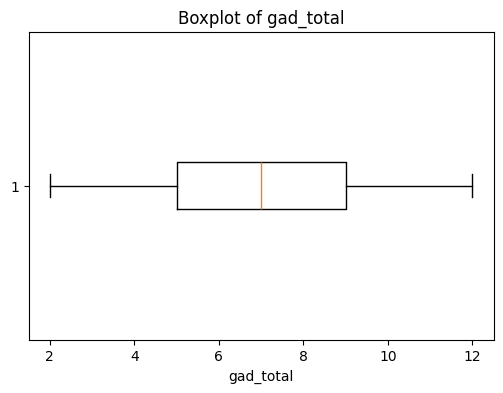

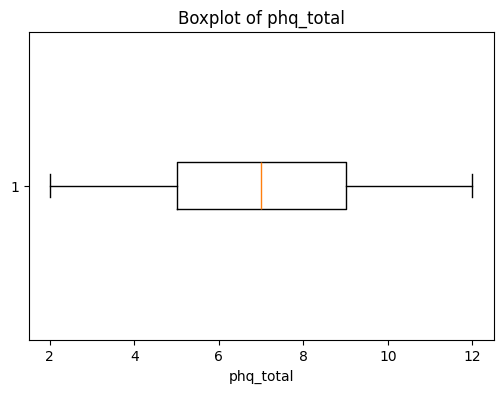

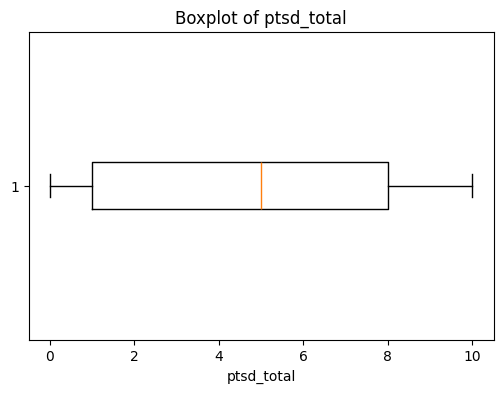

In [ ]:
import matplotlib.pyplot as plt

for col in score_outcomes:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

# Phase 4 : Inferential Analysis

# Tests: 2 GP Comparsions Using Welch T-Test

In [ ]:
from scipy import stats   # Gender
score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']

gender_test_results = []

for outcome in score_outcomes:
    temp = df[[outcome, 'gender_group']].dropna()

    male = temp[temp['gender_group'] == 'Male'][outcome]
    female = temp[temp['gender_group'] == 'Female'][outcome]

    # t-test (always use Welch's t-test for robustness)
    t_stat, t_p = stats.ttest_ind(male, female, equal_var=False)

    # Mann-Whitney U robustness check
    u_stat, u_p = stats.mannwhitneyu(male, female, alternative='two-sided')

    # Cohen's d
    n1, n2 = len(male), len(female)
    mean1, mean2 = male.mean(), female.mean()
    sd1, sd2 = male.std(ddof=1), female.std(ddof=1)

    # Calculate pooled SD for Cohen's d, as ttest_ind with equal_var=False doesn't provide it directly
    # For Welch's t-test, it's more appropriate to use the individual standard deviations for effect size if sample sizes are very different, but pooled SD is common for reporting.
    # Using pooled standard deviation for Cohen's d for consistency with earlier approach. Alternatively, one might consider separate SDs.
    pooled_sd = np.sqrt(((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2) / (n1 + n2 - 2))
    cohens_d = (mean1 - mean2) / pooled_sd

    gender_test_results.append({
        'outcome': outcome,
        'male_n': n1,
        'female_n': n2,
        'male_mean': round(mean1, 3),
        'female_mean': round(mean2, 3),
        'selected_test': 'Welch t-test',
        't_stat': round(t_stat, 3),
        't_p': round(t_p, 4),
        'mannwhitney_p': round(u_p, 4),
        'cohens_d': round(cohens_d, 3)
    })

gender_test_table = pd.DataFrame(gender_test_results)
gender_test_table

,outcome,male_n,female_n,male_mean,female_mean,selected_test,t_stat,t_p,mannwhitney_p,cohens_d
0,gad_total,150,138,7.107,6.667,Welch t-test,1.386,0.1669,0.1842,0.163
1,phq_total,151,137,7.272,6.526,Welch t-test,2.199,0.0287,0.0241,0.258
2,ptsd_total,144,136,4.660,4.860,Welch t-test,-0.474,0.6360,0.6430,-0.057


In [ ]:
# Education Vs Mental Health
from scipy import stats

score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'education_group'

education_results = []

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    groups = temp[predictor].unique()

    group1 = temp[temp[predictor] == groups[0]][outcome]
    group2 = temp[temp[predictor] == groups[1]][outcome]

    # t-test (always use Welch's t-test for robustness)
    t_stat, t_p = stats.ttest_ind(group1, group2, equal_var=False)

    # Mann-Whitney U
    u_stat, u_p = stats.mannwhitneyu(group1, group2, alternative='two-sided')

    # Cohen's d
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = group1.mean(), group2.mean()
    sd1, sd2 = group1.std(ddof=1), group2.std(ddof=1)
    pooled_sd = np.sqrt(((n1 - 1)*sd1**2 + (n2 - 1)*sd2**2) / (n1 + n2 - 2))
    cohens_d = (mean1 - mean2) / pooled_sd

    education_results.append({
        'outcome': outcome,
        'group_1': groups[0],
        'group_1_n': n1,
        'group_1_mean': round(mean1, 3),
        'group_2': groups[1],
        'group_2_n': n2,
        'group_2_mean': round(mean2, 3),
        'selected_test': 'Welch t-test',
        't_stat': round(t_stat, 3),
        't_p': round(t_p, 4),
        'mannwhitney_p': round(u_p, 4),
        'cohens_d': round(cohens_d, 3)
    })

education_test_table = pd.DataFrame(education_results)
education_test_table

,outcome,group_1,group_1_n,group_1_mean,group_2,group_2_n,group_2_mean,selected_test,t_stat,t_p,mannwhitney_p,cohens_d
0,gad_total,Higher education,194,6.706,High school,104,7.481,Welch t-test,-2.376,0.0184,0.0197,-0.286
1,phq_total,Higher education,194,6.809,High school,104,7.221,Welch t-test,-1.167,0.2445,0.2557,-0.141
2,ptsd_total,Higher education,191,4.696,High school,101,5.119,Welch t-test,-0.964,0.3364,0.3474,-0.119


<Figure size 700x500 with 0 Axes>

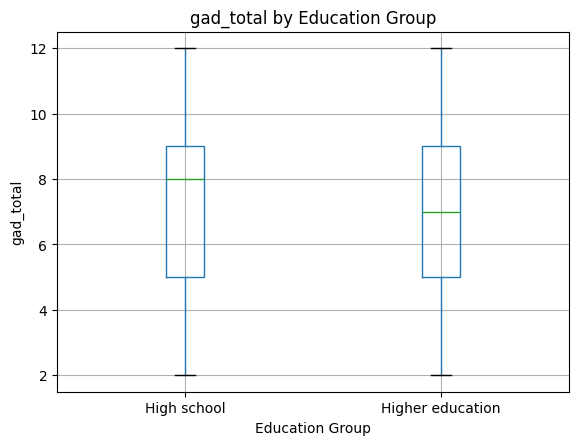

<Figure size 700x500 with 0 Axes>

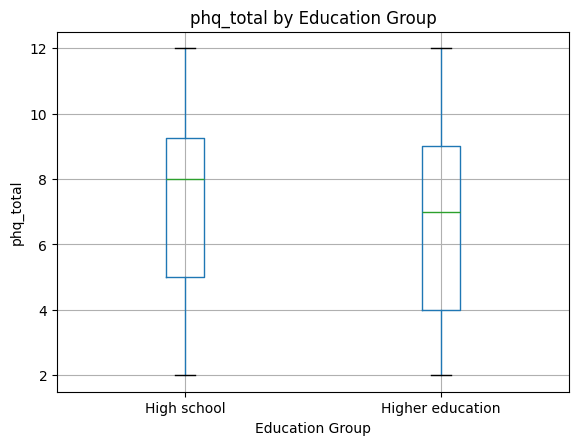

<Figure size 700x500 with 0 Axes>

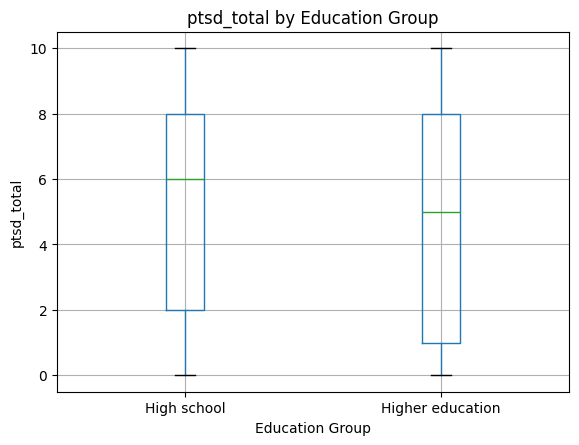

In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    plt.figure(figsize=(7, 5))
    temp.boxplot(column=outcome, by=predictor)
    plt.title(f'{outcome} by Education Group')
    plt.suptitle('')
    plt.xlabel('Education Group')
    plt.ylabel(outcome)
    plt.show()

In [ ]:
from scipy import stats
import pandas as pd
import numpy as np

score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'education_group'

education_results = []

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    groups = temp[predictor].dropna().unique()

    group1_name = groups[0]
    group2_name = groups[1]

    group1 = temp[temp[predictor] == group1_name][outcome]
    group2 = temp[temp[predictor] == group2_name][outcome]

    # t-test / Welch (always use Welch's t-test)
    t_stat, t_p = stats.ttest_ind(group1, group2, equal_var=False)

    # Mann-Whitney U
    u_stat, u_p = stats.mannwhitneyu(group1, group2, alternative='two-sided')

    # Means and SDs
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = group1.mean(), group2.mean()
    sd1, sd2 = group1.std(ddof=1), group2.std(ddof=1)

    # Mean difference
    mean_diff = mean1 - mean2

    # Cohen's d
    pooled_sd = np.sqrt(((n1 - 1)*sd1**2 + (n2 - 1)*sd2**2) / (n1 + n2 - 2))
    cohens_d = mean_diff / pooled_sd

    # 95% CI for mean difference (using Welch's t-test calculation for CI)
    se_diff = np.sqrt((sd1**2/n1) + (sd2**2/n2))
    dfree = ((sd1**2/n1 + sd2**2/n2)**2) / (
        ((sd1**2/n1)**2 / (n1 - 1)) + ((sd2**2/n2)**2 / (n2 - 1))
    )

    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=dfree,
        loc=mean_diff,
        scale=se_diff
    )

    education_results.append({
        'outcome': outcome,
        'group_1': group1_name,
        'group_1_n': n1,
        'group_1_mean': round(mean1, 3),
        'group_2': group2_name,
        'group_2_n': n2,
        'group_2_mean': round(mean2, 3),
        'mean_diff_g1_minus_g2': round(mean_diff, 3),
        'ci_95_low': round(ci_low, 3),
        'ci_95_high': round(ci_high, 3),
        'selected_test': 'Welch t-test',
        't_stat': round(t_stat, 3),
        't_p': round(t_p, 4),
        'mannwhitney_p': round(u_p, 4),
        'cohens_d': round(cohens_d, 3)
    })

education_test_table = pd.DataFrame(education_results)
education_test_table

,outcome,group_1,group_1_n,group_1_mean,group_2,group_2_n,group_2_mean,mean_diff_g1_minus_g2,ci_95_low,ci_95_high,selected_test,t_stat,t_p,mannwhitney_p,cohens_d
0,gad_total,Higher education,194,6.706,High school,104,7.481,-0.775,-1.417,-0.132,Welch t-test,-2.376,0.0184,0.0197,-0.286
1,phq_total,Higher education,194,6.809,High school,104,7.221,-0.412,-1.108,0.284,Welch t-test,-1.167,0.2445,0.2557,-0.141
2,ptsd_total,Higher education,191,4.696,High school,101,5.119,-0.422,-1.287,0.442,Welch t-test,-0.964,0.3364,0.3474,-0.119


In [ ]:
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'living_area'

living_area_results = []

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    groups = temp[predictor].dropna().unique()

    group1_name = groups[0]
    group2_name = groups[1]

    group1 = temp[temp[predictor] == group1_name][outcome]
    group2 = temp[temp[predictor] == group2_name][outcome]

    # t-test / Welch (always use Welch's t-test)
    t_stat, t_p = stats.ttest_ind(group1, group2, equal_var=False)

    # Mann-Whitney U
    u_stat, u_p = stats.mannwhitneyu(group1, group2, alternative='two-sided')

    # Means and SDs
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = group1.mean(), group2.mean()
    sd1, sd2 = group1.std(ddof=1), group2.std(ddof=1)

    # Mean difference
    mean_diff = mean1 - mean2

    # Cohen's d
    pooled_sd = np.sqrt(((n1 - 1)*sd1**2 + (n2 - 1)*sd2**2) / (n1 + n2 - 2))
    cohens_d = mean_diff / pooled_sd

    # 95% CI for mean difference (using Welch's t-test calculation for CI)
    se_diff = np.sqrt((sd1**2/n1) + (sd2**2/n2))
    dfree = ((sd1**2/n1 + sd2**2/n2)**2) / (
        ((sd1**2/n1)**2 / (n1 - 1)) + ((sd2**2/n2)**2 / (n2 - 1))
    )

    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=dfree,
        loc=mean_diff,
        scale=se_diff
    )

    living_area_results.append({
        'outcome': outcome,
        'group_1': group1_name,
        'group_1_n': n1,
        'group_1_mean': round(mean1, 3),
        'group_2': group2_name,
        'group_2_n': n2,
        'group_2_mean': round(mean2, 3),
        'mean_diff_g1_minus_g2': round(mean_diff, 3),
        'ci_95_low': round(ci_low, 3),
        'ci_95_high': round(ci_high, 3),
        'selected_test': 'Welch t-test',
        't_stat': round(t_stat, 3),
        't_p': round(t_p, 4),
        'mannwhitney_p': round(u_p, 4),
        'cohens_d': round(cohens_d, 3)
    })

living_area_test_table = pd.DataFrame(living_area_results)
living_area_test_table

,outcome,group_1,group_1_n,group_1_mean,group_2,group_2_n,group_2_mean,mean_diff_g1_minus_g2,ci_95_low,ci_95_high,selected_test,t_stat,t_p,mannwhitney_p,cohens_d
0,gad_total,"Rural (villages, countryside)",97,7.464,"Urban ( City, Town)",203,6.744,0.720,0.081,1.359,Welch t-test,2.223,0.0273,0.0411,0.266
1,phq_total,"Rural (villages, countryside)",97,7.361,"Urban ( City, Town)",203,6.759,0.602,-0.073,1.278,Welch t-test,1.757,0.0804,0.0960,0.206
2,ptsd_total,"Rural (villages, countryside)",95,5.916,"Urban ( City, Town)",197,4.325,1.591,0.766,2.416,Welch t-test,3.801,0.0002,0.0003,0.459


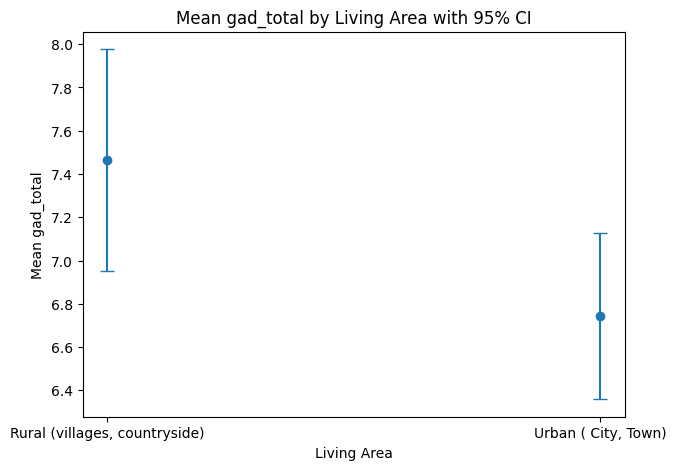

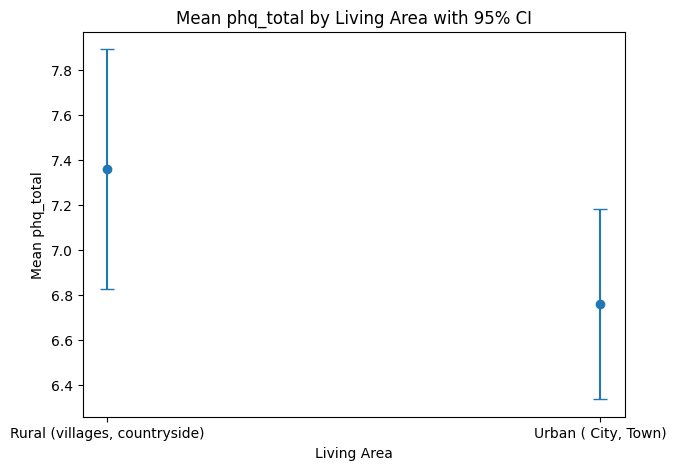

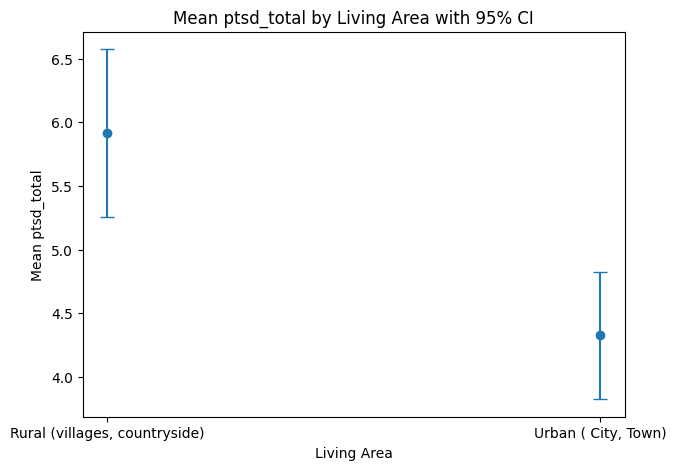

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'living_area'

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    summary = temp.groupby(predictor)[outcome].agg(['mean', 'count', 'std'])
    summary['se'] = summary['std'] / np.sqrt(summary['count'])
    summary['ci95'] = summary['se'] * stats.t.ppf(0.975, summary['count'] - 1)

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        x=summary.index,
        y=summary['mean'],
        yerr=summary['ci95'],
        fmt='o',
        capsize=5
    )
    plt.title(f'Mean {outcome} by Living Area with 95% CI')
    plt.xlabel('Living Area')
    plt.ylabel(f'Mean {outcome}')
    plt.show()

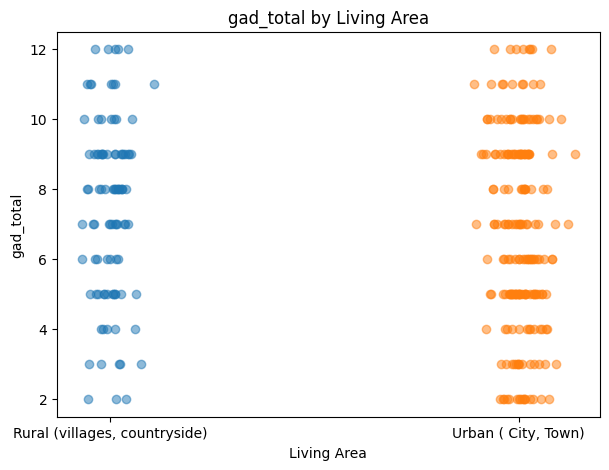

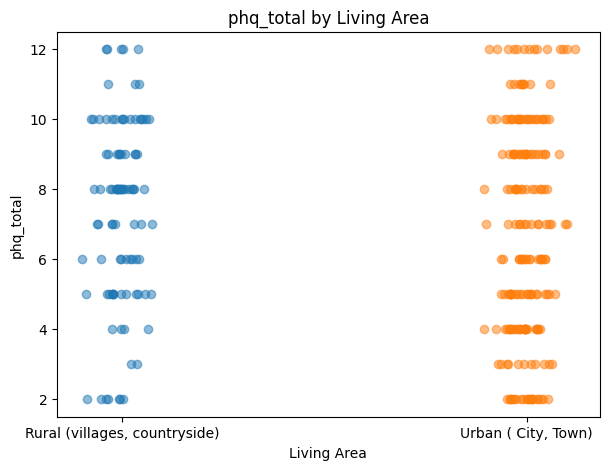

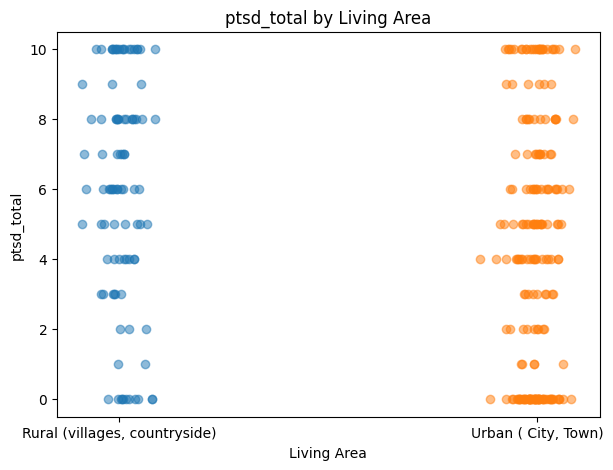

In [ ]:


score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'living_area'

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()
    groups = temp[predictor].unique()

    plt.figure(figsize=(7, 5))

    for i, group in enumerate(groups):
        y = temp[temp[predictor] == group][outcome]
        x = np.random.normal(i + 1, 0.04, size=len(y))
        plt.scatter(x, y, alpha=0.5)

    plt.xticks(range(1, len(groups) + 1), groups)
    plt.title(f'{outcome} by Living Area')
    plt.xlabel('Living Area')
    plt.ylabel(outcome)
    plt.show()

In [ ]:
from scipy import stats # Healthcare_access VS Mental Health

score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'healthcare_access_group'

two_group_results = []

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    groups = temp[predictor].dropna().unique()

    group1_name = groups[0]
    group2_name = groups[1]

    group1 = temp[temp[predictor] == group1_name][outcome]
    group2 = temp[temp[predictor] == group2_name][outcome]

    # t-test / Welch (always use Welch's t-test)
    t_stat, t_p = stats.ttest_ind(group1, group2, equal_var=False)

    # Mann-Whitney U
    u_stat, u_p = stats.mannwhitneyu(group1, group2, alternative='two-sided')

    # Means and SDs
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = group1.mean(), group2.mean()
    sd1, sd2 = group1.std(ddof=1), group2.std(ddof=1)

    # Mean difference
    mean_diff = mean1 - mean2

    # Cohen's d
    pooled_sd = np.sqrt(((n1 - 1)*sd1**2 + (n2 - 1)*sd2**2) / (n1 + n2 - 2))
    cohens_d = mean_diff / pooled_sd

    # 95% CI for mean difference (using Welch's t-test calculation for CI)
    se_diff = np.sqrt((sd1**2/n1) + (sd2**2/n2))
    dfree = ((sd1**2/n1 + sd2**2/n2)**2) / (
        ((sd1**2/n1)**2 / (n1 - 1)) + ((sd2**2/n2)**2 / (n2 - 1))
    )

    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=dfree,
        loc=mean_diff,
        scale=se_diff
    )

    two_group_results.append({
        'outcome': outcome,
        'group_1': group1_name,
        'group_1_n': n1,
        'group_1_mean': round(mean1, 3),
        'group_2': group2_name,
        'group_2_n': n2,
        'group_2_mean': round(mean2, 3),
        'mean_diff_g1_minus_g2': round(mean_diff, 3),
        'ci_95_low': round(ci_low, 3),
        'ci_95_high': round(ci_high, 3),
        'selected_test': 'Welch t-test',
        't_stat': round(t_stat, 3),
        't_p': round(t_p, 4),
        'mannwhitney_p': round(u_p, 4),
        'cohens_d': round(cohens_d, 3)
    })

healthcare_access_test_table = pd.DataFrame(two_group_results)
healthcare_access_test_table

,outcome,group_1,group_1_n,group_1_mean,group_2,group_2_n,group_2_mean,mean_diff_g1_minus_g2,ci_95_low,ci_95_high,selected_test,t_stat,t_p,mannwhitney_p,cohens_d
0,gad_total,Has access,224,6.629,Limited/no access,71,8.028,-1.399,-2.112,-0.686,Welch t-test,-3.884,0.0002,0.0003,-0.525
1,phq_total,Has access,223,6.632,Limited/no access,72,7.889,-1.257,-1.996,-0.517,Welch t-test,-3.363,0.0010,0.0020,-0.434
2,ptsd_total,Has access,217,4.433,Limited/no access,70,5.900,-1.467,-2.394,-0.540,Welch t-test,-3.134,0.0022,0.0027,-0.422


<Figure size 700x500 with 0 Axes>

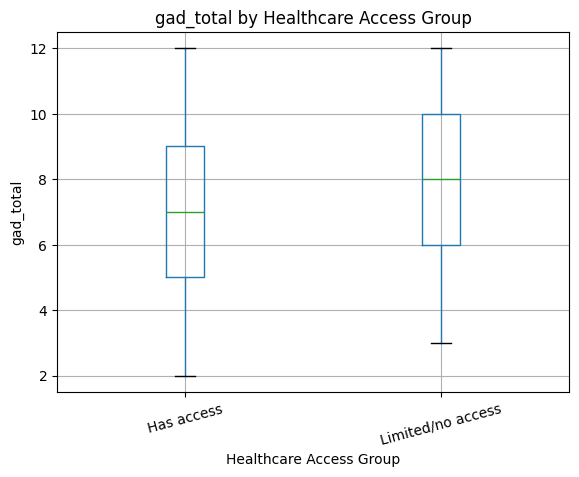

<Figure size 700x500 with 0 Axes>

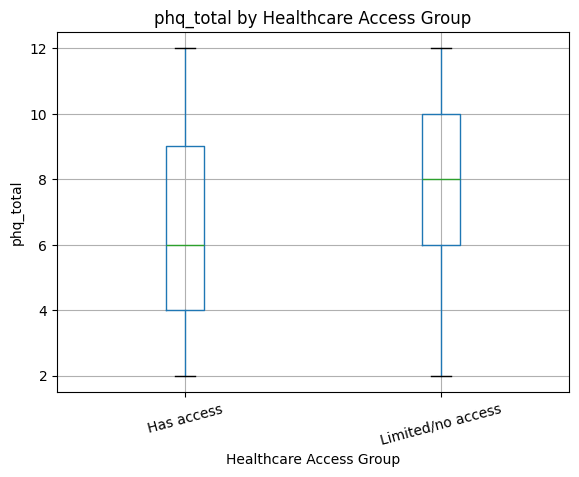

<Figure size 700x500 with 0 Axes>

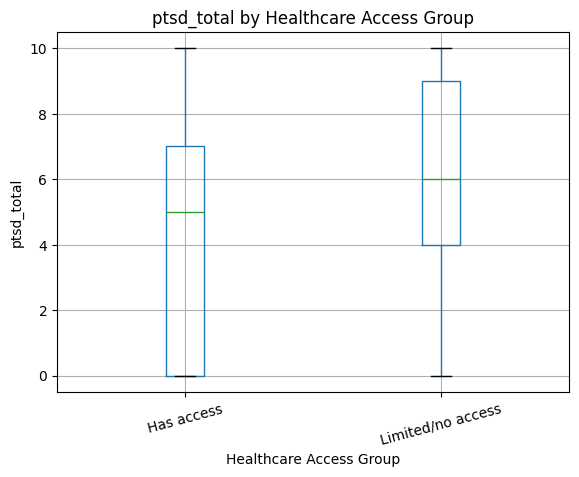

In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    plt.figure(figsize=(7, 5))
    temp.boxplot(column=outcome, by=predictor)
    plt.title(f'{outcome} by Healthcare Access Group')
    plt.suptitle('')
    plt.xlabel('Healthcare Access Group')
    plt.ylabel(outcome)
    plt.xticks(rotation=15)
    plt.show()

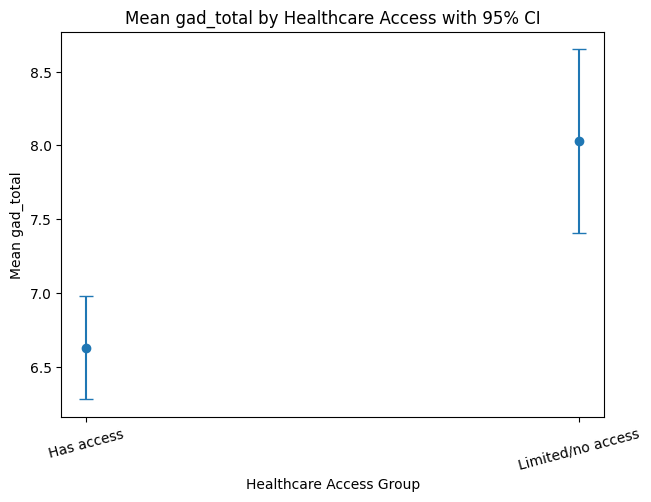

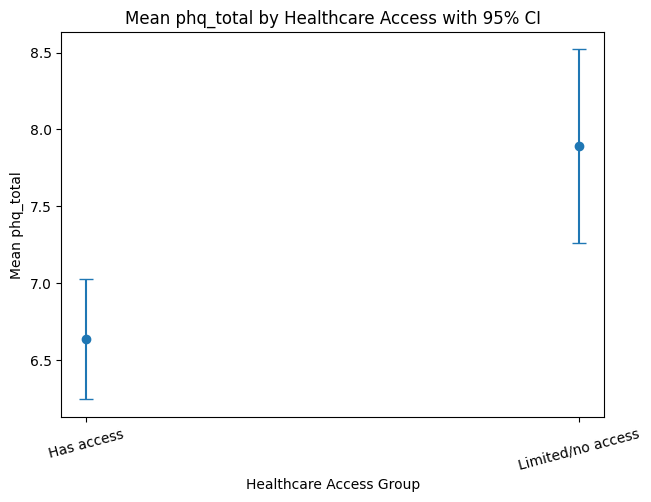

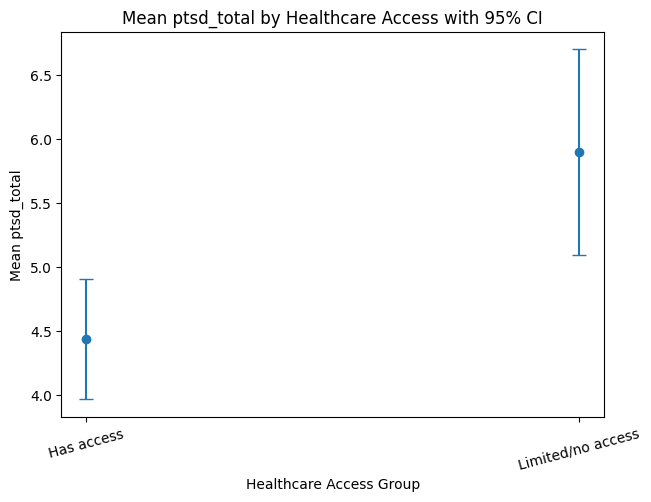

In [ ]:
for outcome in score_outcomes:          # mean plot
    temp = df[[outcome, predictor]].dropna()

    summary = temp.groupby(predictor)[outcome].agg(['mean', 'count', 'std'])
    summary['se'] = summary['std'] / np.sqrt(summary['count'])
    summary['ci95'] = summary['se'] * stats.t.ppf(0.975, summary['count'] - 1)

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        x=summary.index,
        y=summary['mean'],
        yerr=summary['ci95'],
        fmt='o',
        capsize=5
    )
    plt.title(f'Mean {outcome} by Healthcare Access with 95% CI')
    plt.xlabel('Healthcare Access Group')
    plt.ylabel(f'Mean {outcome}')
    plt.xticks(rotation=15)
    plt.show()

In [ ]:
# Housing Status Vs Menatal Health
from scipy import stats

score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'housing_group'

housing_results = []

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    groups = temp[predictor].dropna().unique()

    group1_name = groups[0]
    group2_name = groups[1]

    group1 = temp[temp[predictor] == group1_name][outcome]
    group2 = temp[temp[predictor] == group2_name][outcome]

    # t-test / Welch (always use Welch's t-test)
    t_stat, t_p = stats.ttest_ind(group1, group2, equal_var=False)

    # Mann-Whitney U
    u_stat, u_p = stats.mannwhitneyu(group1, group2, alternative='two-sided')

    # Means and SDs
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = group1.mean(), group2.mean()
    sd1, sd2 = group1.std(ddof=1), group2.std(ddof=1)

    # Mean difference
    mean_diff = mean1 - mean2

    # Cohen's d
    pooled_sd = np.sqrt(((n1 - 1)*sd1**2 + (n2 - 1)*sd2**2) / (n1 + n2 - 2))
    cohens_d = mean_diff / pooled_sd

    # 95% CI for mean difference (using Welch's t-test calculation for CI)
    se_diff = np.sqrt((sd1**2/n1) + (sd2**2/n2))
    dfree = ((sd1**2/n1 + sd2**2/n2)**2) / (
        ((sd1**2/n1)**2 / (n1 - 1)) + ((sd2**2/n2)**2 / (n2 - 1))
    )

    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=dfree,
        loc=mean_diff,
        scale=se_diff
    )

    housing_results.append({
        'outcome': outcome,
        'group_1': group1_name,
        'group_1_n': n1,
        'group_1_mean': round(mean1, 3),
        'group_2': group2_name,
        'group_2_n': n2,
        'group_2_mean': round(mean2, 3),
        'mean_diff_g1_minus_g2': round(mean_diff, 3),
        'ci_95_low': round(ci_low, 3),
        'ci_95_high': round(ci_high, 3),
        'selected_test': 'Welch t-test',
        't_stat': round(t_stat, 3),
        't_p': round(t_p, 4),
        'mannwhitney_p': round(u_p, 4),
        'cohens_d': round(cohens_d, 3)
    })

housing_test_table = pd.DataFrame(housing_results)
housing_test_table

,outcome,group_1,group_1_n,group_1_mean,group_2,group_2_n,group_2_mean,mean_diff_g1_minus_g2,ci_95_low,ci_95_high,selected_test,t_stat,t_p,mannwhitney_p,cohens_d
0,gad_total,Stable housing,189,6.212,Unstable housing,109,8.321,-2.109,-2.692,-1.527,Welch t-test,-7.128,0.0000,0.0000,-0.834
1,phq_total,Stable housing,188,6.452,Unstable housing,110,7.855,-1.402,-2.074,-0.731,Welch t-test,-4.117,0.0001,0.0001,-0.491
2,ptsd_total,Stable housing,184,4.120,Unstable housing,106,6.189,-2.069,-2.878,-1.260,Welch t-test,-5.041,0.0000,0.0000,-0.610


<Figure size 700x500 with 0 Axes>

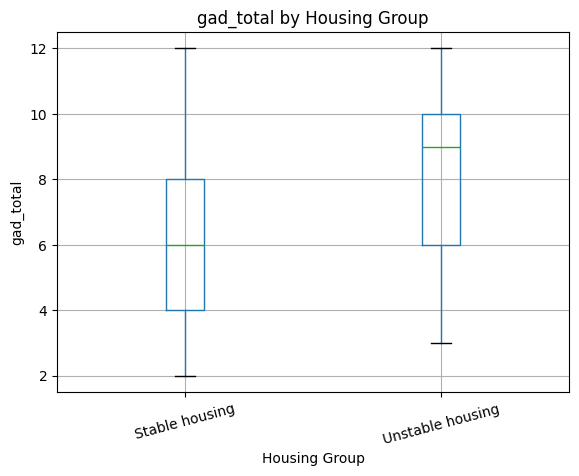

<Figure size 700x500 with 0 Axes>

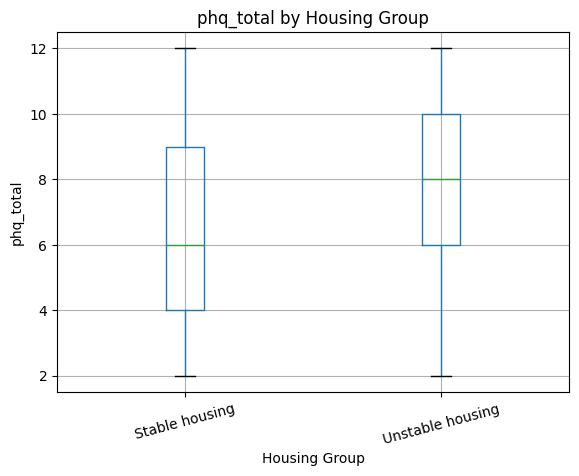

<Figure size 700x500 with 0 Axes>

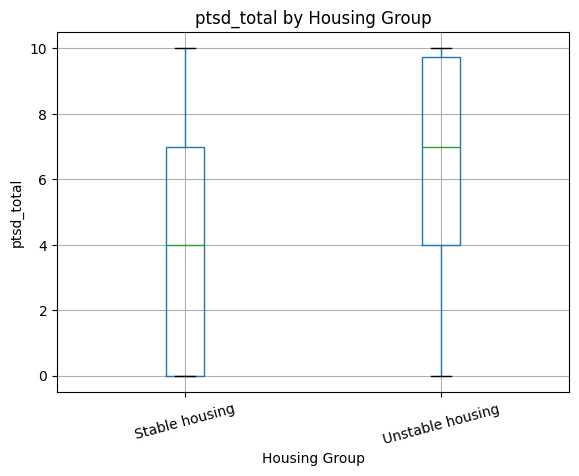

In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    plt.figure(figsize=(7, 5))
    temp.boxplot(column=outcome, by=predictor)
    plt.title(f'{outcome} by Housing Group')
    plt.suptitle('')
    plt.xlabel('Housing Group')
    plt.ylabel(outcome)
    plt.xticks(rotation=15)
    plt.show()

In [ ]:
# Conflict_impact Vs Mental Health
df_conflict = df[df['conflict_impact_group'].isin([
    'No/Mild Impact',
    'Moderate/Severe Impact'
])].copy()


score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'conflict_impact_group'

# Keep only the two meaningful groups
df_conflict = df[df[predictor].isin([
    'No/Mild Impact',
    'Moderate/Severe Impact'
])].copy()

conflict_results = []

for outcome in score_outcomes:
    temp = df_conflict[[outcome, predictor]].dropna()

    groups = temp[predictor].dropna().unique()

    group1_name = groups[0]
    group2_name = groups[1]

    group1 = temp[temp[predictor] == group1_name][outcome]
    group2 = temp[temp[predictor] == group2_name][outcome]

    # Welch t-test
    t_stat, t_p = stats.ttest_ind(group1, group2, equal_var=False)

    # Mann-Whitney U robustness check
    u_stat, u_p = stats.mannwhitneyu(group1, group2, alternative='two-sided')

    # Means and SDs
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = group1.mean(), group2.mean()
    sd1, sd2 = group1.std(ddof=1), group2.std(ddof=1)

    # Mean difference
    mean_diff = mean1 - mean2

    # Cohen's d
    pooled_sd = np.sqrt(
        ((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2) / (n1 + n2 - 2)
    )
    cohens_d = mean_diff / pooled_sd

    # 95% CI for mean difference using Welch calculation
    se_diff = np.sqrt((sd1**2 / n1) + (sd2**2 / n2))

    dfree = ((sd1**2 / n1 + sd2**2 / n2) ** 2) / (
        ((sd1**2 / n1) ** 2 / (n1 - 1)) +
        ((sd2**2 / n2) ** 2 / (n2 - 1))
    )

    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=dfree,
        loc=mean_diff,
        scale=se_diff
    )

    conflict_results.append({
        'outcome': outcome,
        'group_1': group1_name,
        'group_1_n': n1,
        'group_1_mean': round(mean1, 3),
        'group_2': group2_name,
        'group_2_n': n2,
        'group_2_mean': round(mean2, 3),
        'mean_diff_g1_minus_g2': round(mean_diff, 3),
        'ci_95_low': round(ci_low, 3),
        'ci_95_high': round(ci_high, 3),
        'selected_test': 'Welch t-test',
        't_stat': round(t_stat, 3),
        't_p': round(t_p, 4),
        'mannwhitney_p': round(u_p, 4),
        'cohens_d': round(cohens_d, 3)
    })

conflict_test_table = pd.DataFrame(conflict_results)
conflict_test_table

,outcome,group_1,group_1_n,group_1_mean,group_2,group_2_n,group_2_mean,mean_diff_g1_minus_g2,ci_95_low,ci_95_high,selected_test,t_stat,t_p,mannwhitney_p,cohens_d
0,gad_total,No/Mild Impact,80,5.338,Moderate/Severe Impact,204,7.426,-2.089,-2.776,-1.402,Welch t-test,-6.016,0.000,0.0000,-0.818
1,phq_total,No/Mild Impact,79,6.013,Moderate/Severe Impact,205,7.229,-1.217,-1.981,-0.452,Welch t-test,-3.146,0.002,0.0012,-0.428
2,ptsd_total,No/Mild Impact,78,3.205,Moderate/Severe Impact,200,5.295,-2.090,-2.936,-1.244,Welch t-test,-4.878,0.000,0.0000,-0.614


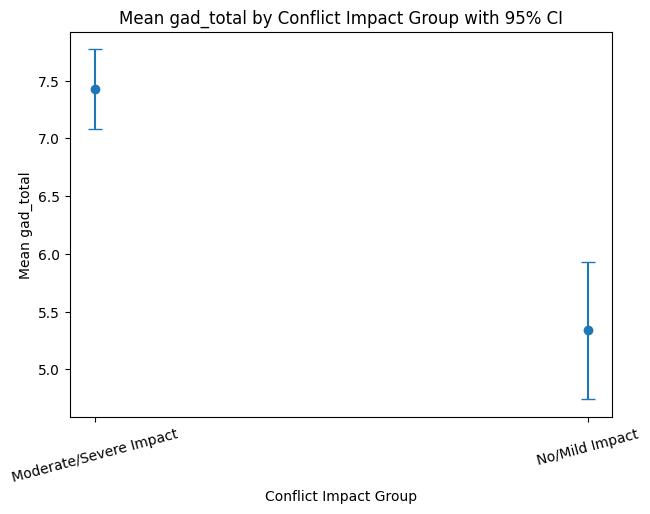

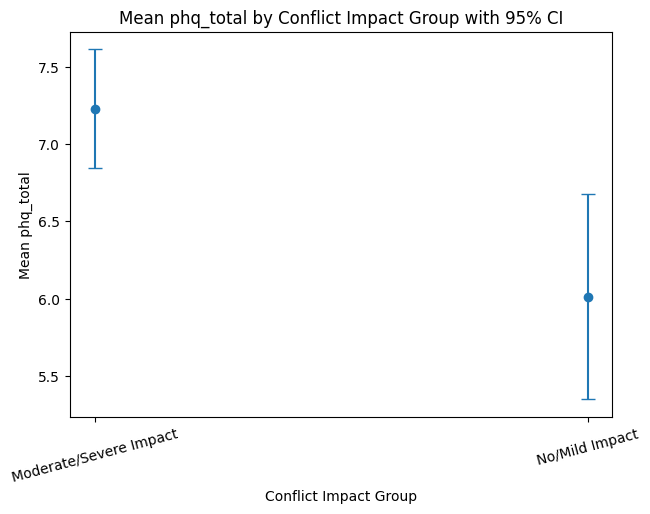

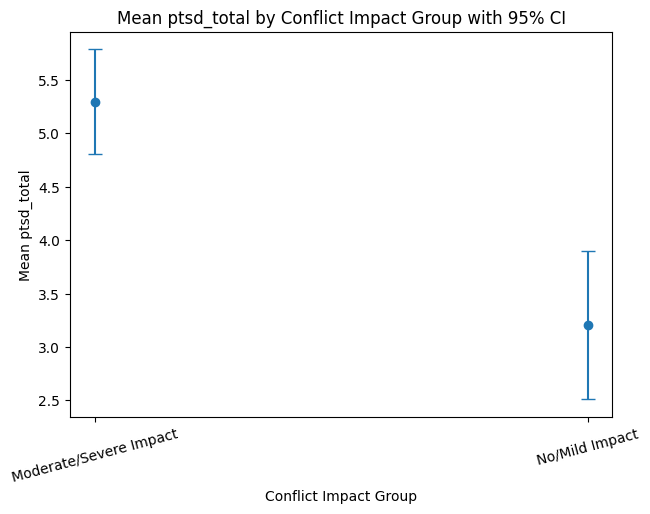

In [ ]:
for outcome in score_outcomes:     # Mean Plot with 95% CI
    temp = df_conflict[[outcome, predictor]].dropna()

    summary = temp.groupby(predictor)[outcome].agg(['mean', 'count', 'std'])
    summary['se'] = summary['std'] / np.sqrt(summary['count'])
    summary['ci95'] = summary['se'] * stats.t.ppf(0.975, summary['count'] - 1)

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        x=summary.index,
        y=summary['mean'],
        yerr=summary['ci95'],
        fmt='o',
        capsize=5
    )
    plt.title(f'Mean {outcome} by Conflict Impact Group with 95% CI')
    plt.xlabel('Conflict Impact Group')
    plt.ylabel(f'Mean {outcome}')
    plt.xticks(rotation=15)
    plt.show()

In [ ]:
welch_t_test_summary_results = []

# Gender vs Mental Health
for index, row in gender_test_table.iterrows():
    welch_t_test_summary_results.append({
        'Predictor': 'gender_group',
        'Outcome': row['outcome'],
        'Group_1': row['male_mean'],
        'Group_2': row['female_mean'],
        't_statistic': row['t_stat'],
        'p_value': row['t_p'],
        'Cohen_d': row['cohens_d']
    })

# Education vs Mental Health
for index, row in education_test_table.iterrows():
    welch_t_test_summary_results.append({
        'Predictor': 'education_group',
        'Outcome': row['outcome'],
        'Group_1': row['group_1_mean'],
        'Group_2': row['group_2_mean'],
        't_statistic': row['t_stat'],
        'p_value': row['t_p'],
        'Cohen_d': row['cohens_d']
    })

# Living Area vs Mental Health
for index, row in living_area_test_table.iterrows():
    welch_t_test_summary_results.append({
        'Predictor': 'living_area',
        'Outcome': row['outcome'],
        'Group_1': row['group_1_mean'],
        'Group_2': row['group_2_mean'],
        't_statistic': row['t_stat'],
        'p_value': row['t_p'],
        'Cohen_d': row['cohens_d']
    })

# Healthcare Access vs Mental Health
for index, row in healthcare_access_test_table.iterrows():
    welch_t_test_summary_results.append({
        'Predictor': 'healthcare_access_group',
        'Outcome': row['outcome'],
        'Group_1': row['group_1_mean'],
        'Group_2': row['group_2_mean'],
        't_statistic': row['t_stat'],
        'p_value': row['t_p'],
        'Cohen_d': row['cohens_d']
    })

# Housing Status vs Mental Health
for index, row in housing_test_table.iterrows():
    welch_t_test_summary_results.append({
        'Predictor': 'housing_group',
        'Outcome': row['outcome'],
        'Group_1': row['group_1_mean'],
        'Group_2': row['group_2_mean'],
        't_statistic': row['t_stat'],
        'p_value': row['t_p'],
        'Cohen_d': row['cohens_d']
    })

# Conflict Impact vs Mental Health
for index, row in conflict_test_table.iterrows():
    welch_t_test_summary_results.append({
        'Predictor': 'conflict_impact_group',
        'Outcome': row['outcome'],
        'Group_1': row['group_1_mean'],
        'Group_2': row['group_2_mean'],
        't_statistic': row['t_stat'],
        'p_value': row['t_p'],
        'Cohen_d': row['cohens_d']
    })

comparative_welch_t_test_summary = pd.DataFrame(welch_t_test_summary_results)
display(comparative_welch_t_test_summary.round(4))

,Predictor,Outcome,Group_1,Group_2,t_statistic,p_value,Cohen_d
0,gender_group,gad_total,7.107,6.667,1.386,0.1669,0.163
1,gender_group,phq_total,7.272,6.526,2.199,0.0287,0.258
2,gender_group,ptsd_total,4.660,4.860,-0.474,0.6360,-0.057
3,education_group,gad_total,6.706,7.481,-2.376,0.0184,-0.286
4,education_group,phq_total,6.809,7.221,-1.167,0.2445,-0.141
5,education_group,ptsd_total,4.696,5.119,-0.964,0.3364,-0.119
6,living_area,gad_total,7.464,6.744,2.223,0.0273,0.266
7,living_area,phq_total,7.361,6.759,1.757,0.0804,0.206
8,living_area,ptsd_total,5.916,4.325,3.801,0.0002,0.459
9,healthcare_access_group,gad_total,6.629,8.028,-3.884,0.0002,-0.525


## Key findings for each predictor:

*   **Gender:**
    *   `phq_total`: There is a statistically significant difference in PHQ scores between genders (p-value = 0.0287, Cohen's d = 0.258), with males having a slightly higher mean PHQ score (7.272) compared to females (6.526).
    *   No significant differences were found for `gad_total` or `ptsd_total`.

*   **Education Group:**
    *   `gad_total`: There is a statistically significant difference in GAD scores (p-value = 0.0184, Cohen's d = -0.286), indicating that individuals with High School education (mean = 7.481) tend to have higher GAD scores than those with Higher Education (mean = 6.706).
    *   No significant differences were observed for `phq_total` or `ptsd_total`.

*   **Living Area:**
    *   `gad_total`: Rural areas (mean = 7.464) show significantly higher GAD scores than urban areas (mean = 6.744) (p-value = 0.0273, Cohen's d = 0.266).
    *   `ptsd_total`: Rural areas (mean = 5.916) also exhibit significantly higher PTSD scores compared to urban areas (mean = 4.325) (p-value = 0.0002, Cohen's d = 0.459). This suggests a moderate effect.
    *   `phq_total`: Not statistically significant at the 0.05 level (p-value = 0.0804).

*   **Healthcare Access Group:**
    *   Significant differences were found across all mental health outcomes, with `Limited/no access` groups consistently reporting higher scores.
    *   `gad_total`: Those with Limited/no access (mean = 8.028) have significantly higher GAD scores than those with Has access (mean = 6.629) (p-value = 0.0002, Cohen's d = -0.525), a moderate effect.
    *   `phq_total`: Similarly, Limited/no access (mean = 7.889) shows higher PHQ scores than Has access (mean = 6.632) (p-value = 0.0010, Cohen's d = -0.434), a moderate effect.
    *   `ptsd_total`: Limited/no access (mean = 5.900) also leads to significantly higher PTSD scores compared to Has access (mean = 4.433) (p-value = 0.0022, Cohen's d = -0.422), a moderate effect.

*   **Housing Group:**
    *   Significant differences are present for all outcomes, with `Unstable housing` groups consistently showing higher distress.
    *   `gad_total`: Unstable housing (mean = 8.321) is associated with significantly higher GAD scores than Stable housing (mean = 6.212) (p-value = 0.0000, Cohen's d = -0.834), a large effect.
    *   `phq_total`: Unstable housing (mean = 7.855) also shows significantly higher PHQ scores than Stable housing (mean = 6.452) (p-value = 0.0001, Cohen's d = -0.491), a moderate effect.
    *   `ptsd_total`: Unstable housing (mean = 6.189) leads to significantly higher PTSD scores than Stable housing (mean = 4.120) (p-value = 0.0000, Cohen's d = -0.610), a moderate to large effect.

*   **Conflict Impact Group:**
    *   Significant differences were found for all mental health outcomes.
    *   `gad_total`: Individuals experiencing `Moderate/Severe Impact` from conflict (mean = 7.426) report significantly higher GAD scores than those with `No/Mild Impact` (mean = 5.338) (p-value = 0.0000, Cohen's d = -0.818), indicating a large effect.
    *   `phq_total`: Moderate/Severe Impact (mean = 7.229) also correlates with higher PHQ scores than No/Mild Impact (mean = 6.013) (p-value = 0.0020, Cohen's d = -0.428), a moderate effect.
    *   `ptsd_total`: Moderate/Severe Impact (mean = 5.295) results in significantly higher PTSD scores compared to No/Mild Impact (mean = 3.205) (p-value = 0.0000, Cohen's d = -0.614), a moderate to large effect.

# Tests: Correlation_Tests

In [ ]:
# Age Vs Mental Health
#Pearson correlation and Spearman correlation
from scipy import stats

score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']

age_corr_results = []

for outcome in score_outcomes:
    temp = df[['age', outcome]].dropna()

    # Pearson correlation
    pearson_r, pearson_p = stats.pearsonr(temp['age'], temp[outcome])

    # Spearman correlation
    spearman_rho, spearman_p = stats.spearmanr(temp['age'], temp[outcome])

    age_corr_results.append({
        'outcome': outcome,
        'n': len(temp),
        'pearson_r': round(pearson_r, 3),
        'pearson_p': round(pearson_p, 4),
        'spearman_rho': round(spearman_rho, 3),
        'spearman_p': round(spearman_p, 4)
    })

age_corr_table = pd.DataFrame(age_corr_results)
age_corr_table

,outcome,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,gad_total,298,-0.172,0.0029,-0.128,0.0269
1,phq_total,298,-0.140,0.0153,-0.145,0.0121
2,ptsd_total,290,-0.224,0.0001,-0.221,0.0002


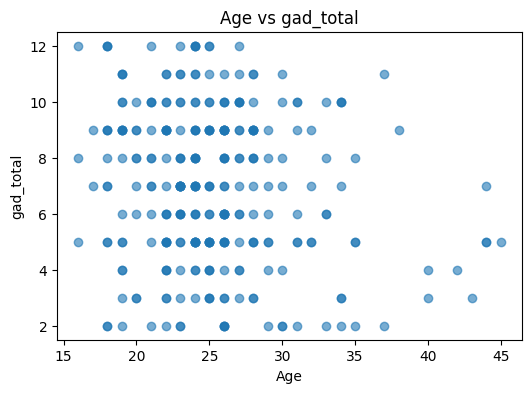

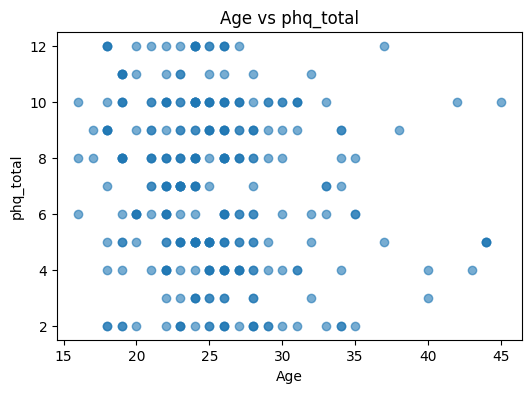

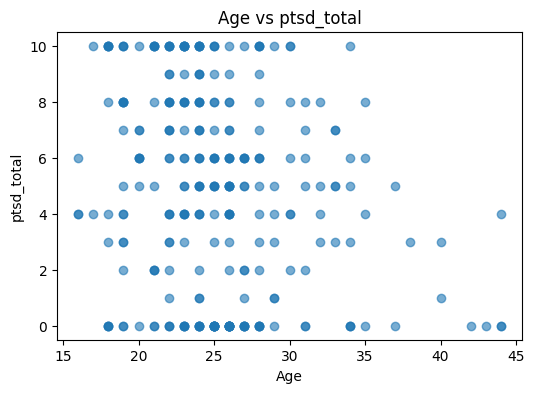

In [ ]:
for outcome in score_outcomes:
    temp = df[['age', outcome]].dropna()

    plt.figure(figsize=(6, 4))
    plt.scatter(temp['age'], temp[outcome], alpha=0.6)
    plt.xlabel('Age')
    plt.ylabel(outcome)
    plt.title(f'Age vs {outcome}')
    plt.show()

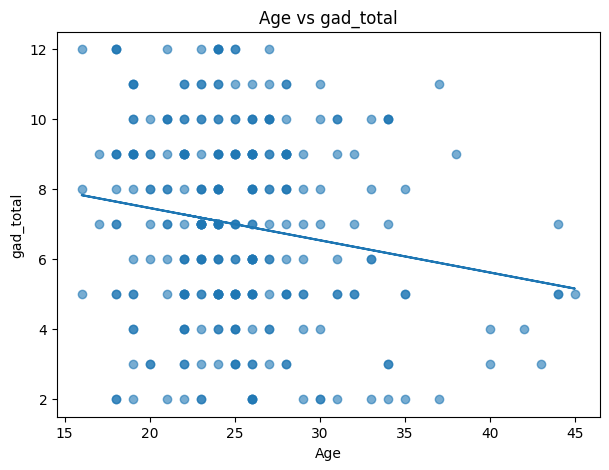

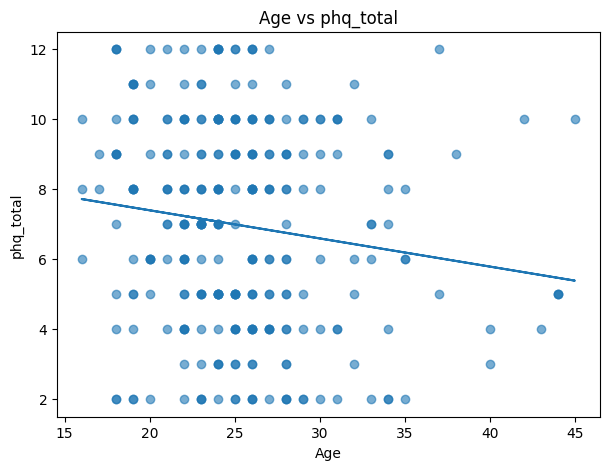

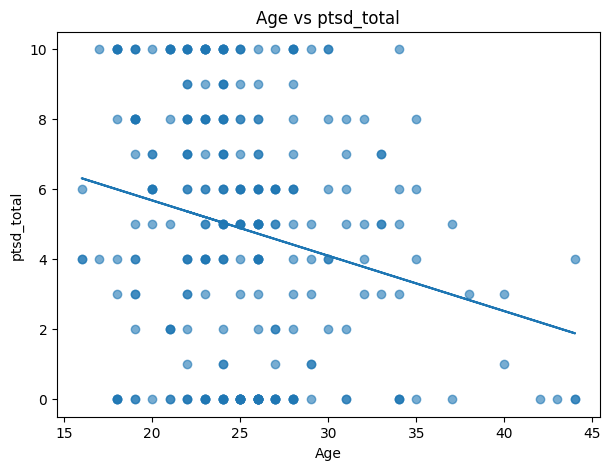

In [ ]:
score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']

for outcome in score_outcomes:
    temp = df[['age', outcome]].dropna()

    x = temp['age']
    y = temp[outcome]

    # Linear trend line
    slope, intercept = np.polyfit(x, y, 1)
    trend_line = slope * x + intercept

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.6)
    plt.plot(x, trend_line)
    plt.xlabel('Age')
    plt.ylabel(outcome)
    plt.title(f'Age vs {outcome}')
    plt.show()

In [ ]:
# Mental health scores with each other
mental_health_scores = ['gad_total', 'phq_total', 'ptsd_total']

corr_results = []

for i in range(len(mental_health_scores)):
    for j in range(i + 1, len(mental_health_scores)):
        var1 = mental_health_scores[i]
        var2 = mental_health_scores[j]

        temp = df[[var1, var2]].dropna()

        pearson_r, pearson_p = stats.pearsonr(temp[var1], temp[var2])
        spearman_rho, spearman_p = stats.spearmanr(temp[var1], temp[var2])

        corr_results.append({
            'variable_1': var1,
            'variable_2': var2,
            'n': len(temp),
            'pearson_r': round(pearson_r, 3),
            'pearson_p': round(pearson_p, 4),
            'spearman_rho': round(spearman_rho, 3),
            'spearman_p': round(spearman_p, 4)
        })

mental_health_corr_table = pd.DataFrame(corr_results)
mental_health_corr_table

,variable_1,variable_2,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,gad_total,phq_total,299,0.345,0.0,0.340,0.0
1,gad_total,ptsd_total,292,0.498,0.0,0.496,0.0
2,phq_total,ptsd_total,291,0.274,0.0,0.269,0.0


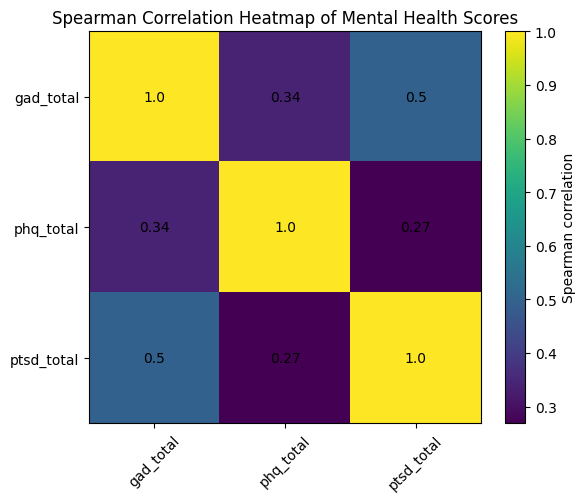

In [ ]:
corr_matrix = df[mental_health_scores].corr(method='spearman')

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix)
plt.colorbar(label='Spearman correlation')

plt.xticks(range(len(mental_health_scores)), mental_health_scores, rotation=45)
plt.yticks(range(len(mental_health_scores)), mental_health_scores)

for i in range(len(mental_health_scores)):
    for j in range(len(mental_health_scores)):
        plt.text(
            j, i,
            round(corr_matrix.iloc[i, j], 2),
            ha='center',
            va='center'
        )

plt.title('Spearman Correlation Heatmap of Mental Health Scores')
plt.tight_layout()
plt.show()

In [ ]:
# Ordinal socioeconomic variables vs mental health
from scipy import stats
import pandas as pd

score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']

ordinal_maps = {
    'income_group': {
        'Low income': 1,
        'Middle income': 2,
        'High income': 3
    },
    'financial_struggle_group': {
        'Low': 1,
        'Moderate': 2,
        'High': 3
    },
    'bill_difficulty_group': {
        'Low': 1,
        'Moderate': 2,
        'High': 3
    },
    'income_stability_group': {
        'Stable': 1,
        'Unstable': 2,
        'No income': 3
    },
    'financial_stress_group': {
        'Low': 1,
        'Moderate': 2,
        'High': 3
    },
    'conflict_impact_group': {
        'No/Mild Impact': 1,  # Corrected mapping
        'Moderate/Severe Impact': 2 # Corrected mapping
    },
    'service_access_group': {
        'Easy': 1,
        'Moderate': 2,
        'Hard': 3
    }
}

ordinal_corr_results = []

for predictor, mapping in ordinal_maps.items():
    numeric_col = predictor + '_num'
    df[numeric_col] = df[predictor].map(mapping)

    for outcome in score_outcomes:
        temp = df[[numeric_col, outcome]].dropna()

        # Only calculate correlation if there are enough data points
        if len(temp) > 1: # Spearmanr requires at least 2 observations
            rho, p_value = stats.spearmanr(temp[numeric_col], temp[outcome])

            ordinal_corr_results.append({
                'predictor': predictor,
                'outcome': outcome,
                'n': len(temp),
                'spearman_rho': round(rho, 3),
                'spearman_p': round(p_value, 4)
            })
        else:
            # Append NaN results if not enough data for correlation
            ordinal_corr_results.append({
                'predictor': predictor,
                'outcome': outcome,
                'n': len(temp),
                'spearman_rho': np.nan,
                'spearman_p': np.nan
            })

ordinal_corr_table = pd.DataFrame(ordinal_corr_results)
ordinal_corr_table

,predictor,outcome,n,spearman_rho,spearman_p
0,income_group,gad_total,298,-0.351,0.0000
1,income_group,phq_total,298,-0.264,0.0000
2,income_group,ptsd_total,290,-0.360,0.0000
3,financial_struggle_group,gad_total,294,0.452,0.0000
4,financial_struggle_group,phq_total,294,0.247,0.0000
5,financial_struggle_group,ptsd_total,287,0.351,0.0000
6,bill_difficulty_group,gad_total,295,0.380,0.0000
7,bill_difficulty_group,phq_total,295,0.181,0.0018
8,bill_difficulty_group,ptsd_total,287,0.278,0.0000
9,income_stability_group,gad_total,290,0.283,0.0000


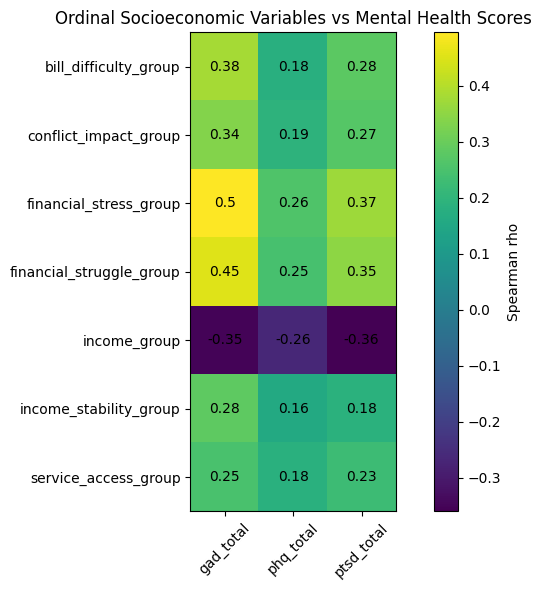

In [ ]:
heatmap_data = ordinal_corr_table.pivot(
    index='predictor',
    columns='outcome',
    values='spearman_rho'
)

plt.figure(figsize=(8, 6))
plt.imshow(heatmap_data)
plt.colorbar(label='Spearman rho')

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        plt.text(
            j, i,
            round(heatmap_data.iloc[i, j], 2),
            ha='center',
            va='center'
        )

plt.title('Ordinal Socioeconomic Variables vs Mental Health Scores')
plt.tight_layout()
plt.show()

In [ ]:
df['conflict_impact_group'].value_counts(dropna=False)

,count
conflict_impact_group,
Moderate/Severe Impact,205
No/Mild Impact,80
Other,13
NaN,3


In [ ]:

correlation_summary = pd.concat([age_corr_table, mental_health_corr_table, ordinal_corr_table])

# Reset index for a cleaner look if desired
correlation_summary = correlation_summary.reset_index(drop=True)

print("\nSummary of Correlation Tests:")
display(correlation_summary.round(4))


Summary of Correlation Tests:


,outcome,n,pearson_r,pearson_p,spearman_rho,spearman_p,variable_1,variable_2,predictor
0,gad_total,298,-0.172,0.0029,-0.128,0.0269,NaN,NaN,NaN
1,phq_total,298,-0.140,0.0153,-0.145,0.0121,NaN,NaN,NaN
2,ptsd_total,290,-0.224,0.0001,-0.221,0.0002,NaN,NaN,NaN
3,NaN,299,0.345,0.0000,0.340,0.0000,gad_total,phq_total,NaN
4,NaN,292,0.498,0.0000,0.496,0.0000,gad_total,ptsd_total,NaN
5,NaN,291,0.274,0.0000,0.269,0.0000,phq_total,ptsd_total,NaN
6,gad_total,298,NaN,NaN,-0.351,0.0000,NaN,NaN,income_group
7,phq_total,298,NaN,NaN,-0.264,0.0000,NaN,NaN,income_group
8,ptsd_total,290,NaN,NaN,-0.360,0.0000,NaN,NaN,income_group
9,gad_total,294,NaN,NaN,0.452,0.0000,NaN,NaN,financial_struggle_group


## Key Findings from Correlation Tests:
Age vs. Mental Health Scores:

 *GAD Total: There is a small but significant negative correlation between age and GAD total scores (Pearson r = -0.172, p < 0.01; Spearman rho = -0.128, p < 0.05), suggesting that as age increases, GAD scores tend to slightly decrease.
* PHQ Total: A small but significant negative correlation exists between age and PHQ total scores (Pearson r = -0.140, p < 0.05; Spearman rho = -0.145, p < 0.05), indicating a slight decrease in PHQ scores with increasing age.
* PTSD Total: A moderate and highly significant negative correlation was found between age and PTSD total scores (Pearson r = -0.224, p < 0.001; Spearman rho = -0.221, p < 0.001), suggesting that younger individuals tend to report higher PTSD scores.
* Mental Health Scores with Each Other:

* GAD Total and PHQ Total: There is a moderate, highly significant positive correlation between GAD total and PHQ total scores (Pearson r = 0.345, p < 0.001; Spearman rho = 0.340, p < 0.001). This indicates that individuals with higher GAD scores also tend to have higher PHQ scores.
* GAD Total and PTSD Total: A strong, highly significant positive correlation exists between GAD total and PTSD total scores (Pearson r = 0.498, p < 0.001; Spearman rho = 0.496, p < 0.001).

This suggests a strong relationship where higher GAD scores are associated with higher PTSD scores.
* PHQ Total and PTSD Total: A small to moderate, highly significant positive correlation was observed between PHQ total and PTSD total scores (Pearson r = 0.274, p < 0.001; Spearman rho = 0.269, p < 0.001). This indicates that higher PHQ scores are related to higher PTSD scores.
* Ordinal Socioeconomic Variables vs. Mental Health Scores (Spearman's Rho):

* Income Group: Shows significant negative correlations with all mental health outcomes (rho values around -0.26 to -0.36, all p < 0.001), meaning lower income is associated with higher mental health distress.
* Financial Struggle, Bill Difficulty, Financial Stress: All show significant positive correlations with all mental health outcomes (rho values ranging from 0.18 to 0.49, all p < 0.01). This consistently indicates that greater financial struggle, difficulty with bills, and stress are associated with higher mental health distress.
* Income Stability Group: Shows significant positive correlations with all mental health outcomes (rho values around 0.16 to 0.28, all p < 0.01), suggesting that less stable income is associated with higher distress.
Conflict Impact Group: Shows significant positive correlations with all mental health outcomes (rho values around 0.19 to 0.34, all p < 0.001), indicating that greater conflict impact is associated with higher mental health distress.
* Service Access Group: Shows significant positive correlations with all mental health outcomes (rho values around 0.18 to 0.25, all p < 0.01), suggesting that harder access to services is associated with higher mental health distress.
* In summary, mental health scores are positively correlated with each other, and age is negatively correlated with mental health distress. Socioeconomic factors like income, financial stability, and access to services show significant correlations with mental health outcomes, generally indicating that adverse socioeconomic conditions are linked to higher levels of mental health distress.

# **Tests: ANOVA**


In [ ]:
# Employment GP Vs Mental Health Scores
score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'employment_group'

anova_results = []

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    groups = [
        group[outcome].values
        for name, group in temp.groupby(predictor)
    ]

    group_summary = temp.groupby(predictor)[outcome].agg(['count', 'mean', 'std']).reset_index()

    # Levene's test
    levene_stat, levene_p = stats.levene(*groups)

    # One-way ANOVA
    f_stat, anova_p = stats.f_oneway(*groups)

    # Kruskal-Wallis
    h_stat, kruskal_p = stats.kruskal(*groups)

    # Eta-squared
    grand_mean = temp[outcome].mean()
    ss_between = sum(
        len(group[outcome]) * (group[outcome].mean() - grand_mean) ** 2
        for name, group in temp.groupby(predictor)
    )
    ss_total = sum((temp[outcome] - grand_mean) ** 2)
    eta_squared = ss_between / ss_total

    anova_results.append({
        'predictor': predictor,
        'outcome': outcome,
        'n': len(temp),
        'groups': temp[predictor].nunique(),
        'levene_p': round(levene_p, 4),
        'anova_f': round(f_stat, 3),
        'anova_p': round(anova_p, 4),
        'kruskal_h': round(h_stat, 3),
        'kruskal_p': round(kruskal_p, 4),
        'eta_squared': round(eta_squared, 3),
        'group_summary': group_summary[[predictor, 'count', 'mean']].to_dict('records')
    })

employment_anova_table = pd.DataFrame(anova_results)
employment_anova_table

,predictor,outcome,n,groups,levene_p,anova_f,anova_p,kruskal_h,kruskal_p,eta_squared,group_summary
0,employment_group,gad_total,298,3,0.8088,3.130,0.0452,5.312,0.0702,0.021,"[{'employment_group': 'Employed', 'count': 189..."
1,employment_group,phq_total,298,3,0.1623,0.333,0.7169,0.815,0.6652,0.002,"[{'employment_group': 'Employed', 'count': 189..."
2,employment_group,ptsd_total,290,3,0.6786,2.706,0.0685,5.635,0.0598,0.019,"[{'employment_group': 'Employed', 'count': 184..."


<Figure size 800x500 with 0 Axes>

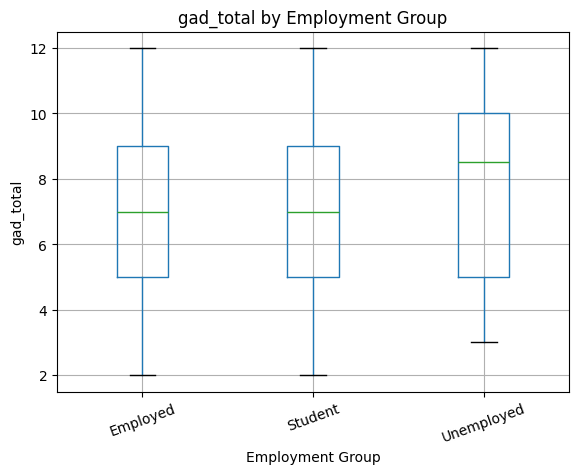

<Figure size 800x500 with 0 Axes>

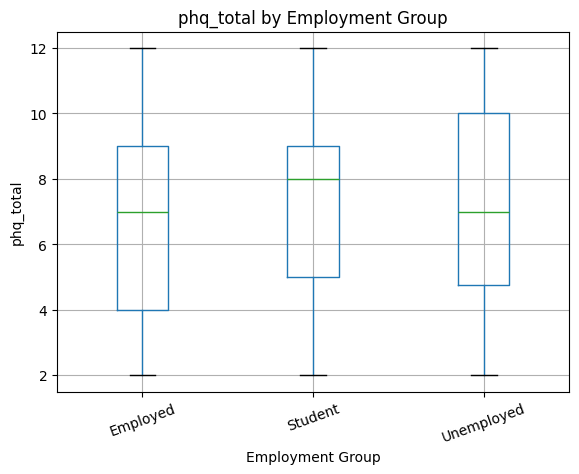

<Figure size 800x500 with 0 Axes>

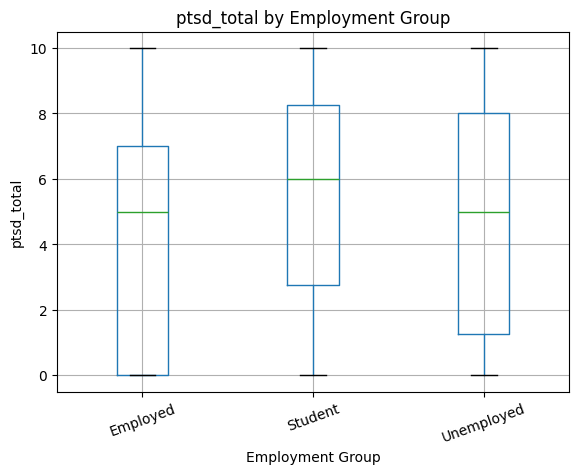

In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    plt.figure(figsize=(8, 5))
    temp.boxplot(column=outcome, by=predictor)
    plt.title(f'{outcome} by Employment Group')
    plt.suptitle('')
    plt.xlabel('Employment Group')
    plt.ylabel(outcome)
    plt.xticks(rotation=20)
    plt.show()

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

temp = df[['gad_total', 'employment_group']].dropna()

tukey_gad_employment = pairwise_tukeyhsd(
    endog=temp['gad_total'],
    groups=temp['employment_group'],
    alpha=0.05
)

print(tukey_gad_employment)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1    group2   meandiff p-adj   lower  upper  reject
---------------------------------------------------------
Employed    Student   0.1063  0.958 -0.7906 1.0032  False
Employed Unemployed   1.1722 0.0356  0.0624  2.282   True
 Student Unemployed   1.0659 0.1186 -0.2012 2.3331  False
---------------------------------------------------------


In [ ]:
score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'income_group'

income_welch_results = []

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    # Welch ANOVA
    welch = pg.welch_anova(
        data=temp,
        dv=outcome,
        between=predictor
    )

    # Kruskal-Wallis robustness check
    groups = [
        group[outcome].values
        for name, group in temp.groupby(predictor)
    ]

    h_stat, kruskal_p = stats.kruskal(*groups)

    # Group summary
    group_summary = temp.groupby(predictor)[outcome].agg(
        ['count', 'mean', 'std']
    ).reset_index()

    income_welch_results.append({
        'predictor': predictor,
        'outcome': outcome,
        'n': len(temp),
        'groups': temp[predictor].nunique(),
        'welch_F': round(welch.loc[0, 'F'], 3),
        'welch_p': round(welch.loc[0, 'p_unc'], 4), # Corrected 'p-unc' to 'p_unc'
        'welch_np2': round(welch.loc[0, 'np2'], 3),
        'kruskal_H': round(h_stat, 3),
        'kruskal_p': round(kruskal_p, 4),
        'group_summary': group_summary[[predictor, 'count', 'mean']].to_dict('records')
    })

income_welch_table = pd.DataFrame(income_welch_results)
income_welch_table

,predictor,outcome,n,groups,welch_F,welch_p,welch_np2,kruskal_H,kruskal_p,group_summary
0,income_group,gad_total,298,3,23.798,0.0,0.145,40.687,0.0,"[{'income_group': 'High income', 'count': 73, ..."
1,income_group,phq_total,298,3,11.333,0.0,0.075,22.646,0.0,"[{'income_group': 'High income', 'count': 72, ..."
2,income_group,ptsd_total,290,3,24.811,0.0,0.136,39.681,0.0,"[{'income_group': 'High income', 'count': 71, ..."


In [ ]:
for outcome in score_outcomes: # post-hoc for income
    temp = df[[outcome, predictor]].dropna()

    welch = pg.welch_anova(
        data=temp,
        dv=outcome,
        between=predictor
    )

    p_value = welch.loc[0, 'p_unc'] # Corrected 'p-unc' to 'p_unc'

    if p_value < 0.05:
        print('\n' + '='*60)
        print(f'Games-Howell post-hoc for {outcome}')

        gh = pg.pairwise_gameshowell(
            data=temp,
            dv=outcome,
            between=predictor
        )

        print(gh.to_string())


Games-Howell post-hoc for gad_total
             A              B    mean_A    mean_B      diff        se         T          df          pval    hedges
0  High income     Low income  5.260274  7.898305 -2.638031  0.383174 -6.884686  145.772014  4.798208e-10 -1.035538
1  High income  Middle income  5.260274  7.149533 -1.889259  0.391720 -4.822984  149.775897  1.025266e-05 -0.735786
2   Low income  Middle income  7.898305  7.149533  0.748772  0.332788  2.249996  220.369436  6.525204e-02  0.299508

Games-Howell post-hoc for phq_total
             A              B    mean_A    mean_B      diff        se         T          df      pval    hedges
0  High income     Low income  5.625000  7.680672 -2.055672  0.432892 -4.748699  149.884025  0.000014 -0.706202
1  High income  Middle income  5.625000  7.056075 -1.431075  0.429468 -3.332203  144.621787  0.003123 -0.513227
2   Low income  Middle income  7.680672  7.056075  0.624598  0.371912  1.679421  223.766935  0.215344  0.222110

Games-Howell 

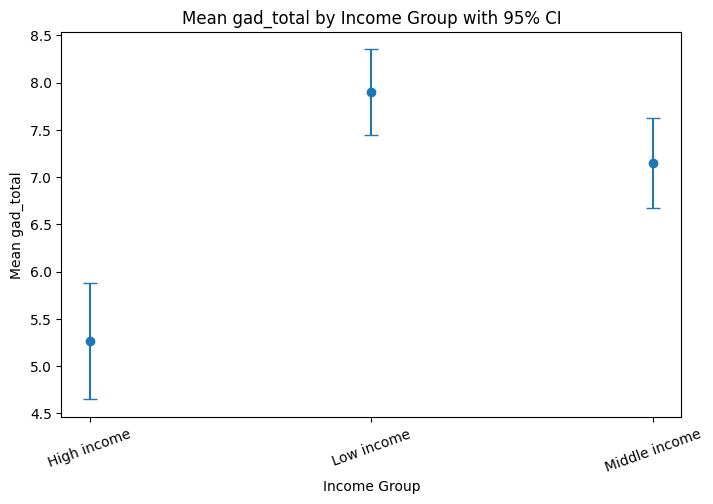

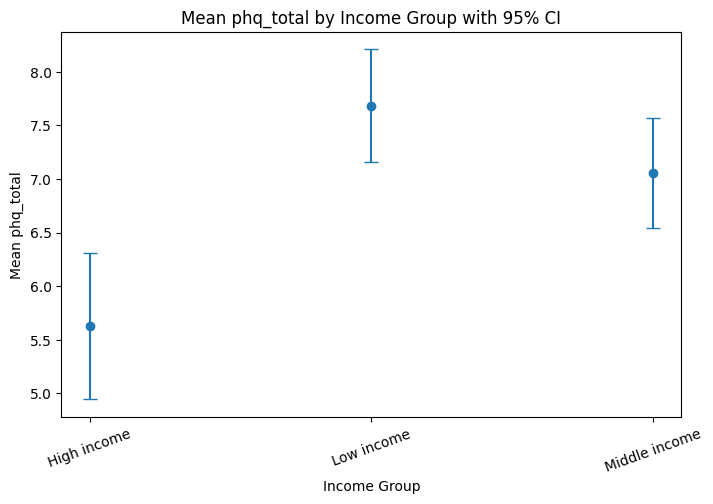

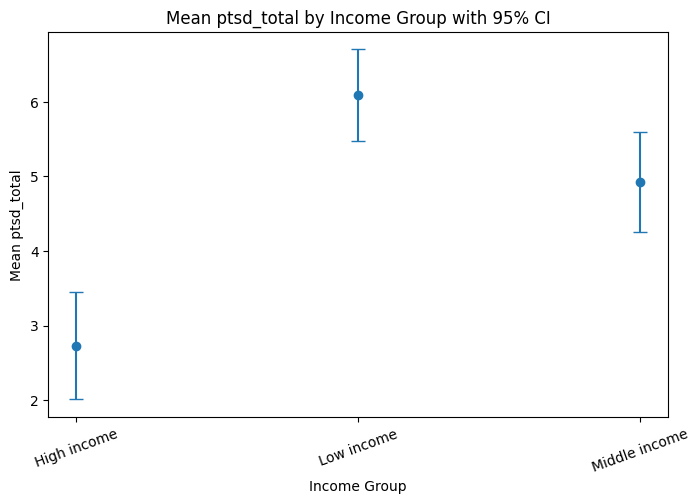

In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    summary = temp.groupby(predictor)[outcome].agg(['mean', 'count', 'std'])
    summary['se'] = summary['std'] / np.sqrt(summary['count'])
    summary['ci95'] = summary['se'] * stats.t.ppf(0.975, summary['count'] - 1)

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        x=summary.index,
        y=summary['mean'],
        yerr=summary['ci95'],
        fmt='o',
        capsize=5
    )
    plt.title(f'Mean {outcome} by Income Group with 95% CI')
    plt.xlabel('Income Group')
    plt.ylabel(f'Mean {outcome}')
    plt.xticks(rotation=20)
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import pingouin as pg
from scipy import stats
import matplotlib.pyplot as plt

score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'financial_stress_group'

financial_stress_results = []

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    # Welch ANOVA
    welch = pg.welch_anova(
        data=temp,
        dv=outcome,
        between=predictor
    )

    # Kruskal-Wallis robustness check
    groups = [
        group[outcome].values
        for name, group in temp.groupby(predictor)
    ]

    h_stat, kruskal_p = stats.kruskal(*groups)

    # Group summary
    group_summary = temp.groupby(predictor)[outcome].agg(
        ['count', 'mean', 'std']
    ).reset_index()

    financial_stress_results.append({
        'predictor': predictor,
        'outcome': outcome,
        'n': len(temp),
        'groups': temp[predictor].nunique(),
        'welch_F': round(welch.loc[0, 'F'], 3),
        'welch_p': round(welch.loc[0, 'p_unc'], 4),
        'welch_np2': round(welch.loc[0, 'np2'], 3),
        'kruskal_H': round(h_stat, 3),
        'kruskal_p': round(kruskal_p, 4),
        'group_summary': group_summary[[predictor, 'count', 'mean']].to_dict('records')
    })

financial_stress_welch_table = pd.DataFrame(financial_stress_results)
financial_stress_welch_table

,predictor,outcome,n,groups,welch_F,welch_p,welch_np2,kruskal_H,kruskal_p,group_summary
0,financial_stress_group,gad_total,296,3,45.292,0.0,0.247,72.401,0.0,"[{'financial_stress_group': 'High', 'count': 1..."
1,financial_stress_group,phq_total,296,3,10.658,0.0,0.075,22.177,0.0,"[{'financial_stress_group': 'High', 'count': 1..."
2,financial_stress_group,ptsd_total,289,3,25.457,0.0,0.151,42.368,0.0,"[{'financial_stress_group': 'High', 'count': 1..."


In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    welch = pg.welch_anova(
        data=temp,
        dv=outcome,
        between=predictor
    )

    p_value = welch.loc[0, 'p_unc']

    if p_value < 0.05:
        print('\n' + '='*60)
        print(f'Games-Howell post-hoc for {outcome}')

        gh = pg.pairwise_gameshowell(
            data=temp,
            dv=outcome,
            between=predictor
        )

        display(gh)


Games-Howell post-hoc for gad_total


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,High,Low,8.345588,4.984615,3.360973,0.379177,8.863853,114.244628,5.340173e-14,1.385781
1,High,Moderate,8.345588,6.389474,1.956115,0.310157,6.306844,202.775911,5.250402e-09,0.840124
2,Low,Moderate,4.984615,6.389474,-1.404858,0.400734,-3.505712,126.889529,1.812450e-03,-0.573969



Games-Howell post-hoc for phq_total


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,High,Low,7.635036,5.569231,2.065806,0.446714,4.624447,118.756577,0.000029,0.710160
1,High,Moderate,7.635036,6.978723,0.656313,0.365702,1.794666,208.268076,0.173870,0.236657
2,Low,Moderate,5.569231,6.978723,-1.409493,0.464635,-3.033548,125.786064,0.008205,-0.498755



Games-Howell post-hoc for ptsd_total


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,High,Low,5.985075,2.412698,3.572376,0.499630,7.150041,123.038778,2.028269e-10,1.082535
1,High,Moderate,5.985075,4.782609,1.202466,0.444855,2.703051,196.788078,2.033705e-02,0.364189
2,Low,Moderate,2.412698,4.782609,-2.369910,0.533675,-4.440734,133.868237,5.501797e-05,-0.721867


In [ ]:
import pandas as pd
import numpy as np
import pingouin as pg
from scipy import stats
import matplotlib.pyplot as plt

score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'financial_struggle_group'

financial_struggle_results = []

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    # Welch ANOVA
    welch = pg.welch_anova(
        data=temp,
        dv=outcome,
        between=predictor
    )

    # Detect p-value column safely
    if 'p_unc' in welch.columns: # Fixed: changed 'p-unc' to 'p_unc'
        p_col = 'p_unc'
    elif 'pval' in welch.columns:
        p_col = 'pval'
    elif 'p' in welch.columns:
        p_col = 'p'
    else:
        print(welch.columns)
        raise KeyError("Could not find p-value column.")

    # Kruskal-Wallis robustness check
    groups = [
        group[outcome].values
        for name, group in temp.groupby(predictor)
    ]

    h_stat, kruskal_p = stats.kruskal(*groups)

    # Group summary
    group_summary = temp.groupby(predictor)[outcome].agg(
        ['count', 'mean', 'std']
    ).reset_index()

    financial_struggle_results.append({
        'predictor': predictor,
        'outcome': outcome,
        'n': len(temp),
        'groups': temp[predictor].nunique(),
        'welch_F': round(welch.loc[0, 'F'], 3),
        'welch_p': round(welch.loc[0, p_col], 4),
        'welch_np2': round(welch.loc[0, 'np2'], 3) if 'np2' in welch.columns else np.nan,
        'kruskal_H': round(h_stat, 3),
        'kruskal_p': round(kruskal_p, 4),
        'group_summary': group_summary[[predictor, 'count', 'mean']].to_dict('records')
    })

financial_struggle_welch_table = pd.DataFrame(financial_struggle_results)
financial_struggle_welch_table

,predictor,outcome,n,groups,welch_F,welch_p,welch_np2,kruskal_H,kruskal_p,group_summary
0,financial_struggle_group,gad_total,294,3,39.613,0.0000,0.214,61.562,0.0000,"[{'financial_struggle_group': 'High', 'count':..."
1,financial_struggle_group,phq_total,294,3,9.906,0.0001,0.067,19.742,0.0001,"[{'financial_struggle_group': 'High', 'count':..."
2,financial_struggle_group,ptsd_total,287,3,22.203,0.0000,0.135,37.791,0.0000,"[{'financial_struggle_group': 'High', 'count':..."


In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    welch = pg.welch_anova(
        data=temp,
        dv=outcome,
        between=predictor
    )

    if 'p_unc' in welch.columns:
        p_col = 'p_unc'
    elif 'pval' in welch.columns:
        p_col = 'pval'
    elif 'p' in welch.columns:
        p_col = 'p'
    else:
        print(welch.columns)
        raise KeyError("Could not find p-value column.")

    p_value = welch.loc[0, p_col]

    if p_value < 0.05:
        print('\n' + '='*60)
        print(f'Games-Howell post-hoc for {outcome}')

        gh = pg.pairwise_gameshowell(
            data=temp,
            dv=outcome,
            between=predictor
        )

        display(gh)


Games-Howell post-hoc for gad_total


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,High,Low,8.208,4.680000,3.528000,0.408942,8.627143,86.395601,8.536505e-13,1.468792
1,High,Moderate,8.208,6.605042,1.602958,0.311698,5.142669,239.090801,1.684920e-06,0.657597
2,Low,Moderate,4.680,6.605042,-1.925042,0.418973,-4.594669,92.992730,4.021630e-05,-0.767448



Games-Howell post-hoc for phq_total


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,High,Low,7.595238,5.440000,2.155238,0.484545,4.447964,94.126388,0.000070,0.724940
1,High,Moderate,7.595238,6.822034,0.773204,0.362964,2.130250,241.379204,0.085911,0.271012
2,Low,Moderate,5.440000,6.822034,-1.382034,0.473023,-2.921704,86.918138,0.012216,-0.504683



Games-Howell post-hoc for ptsd_total


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,High,Low,6.065574,2.367347,3.698227,0.558821,6.617908,89.334658,7.846147e-09,1.110142
1,High,Moderate,6.065574,4.629310,1.436263,0.429924,3.340735,235.521447,2.784266e-03,0.431794
2,Low,Moderate,2.367347,4.629310,-2.261963,0.562059,-4.024420,90.645142,3.454204e-04,-0.681636


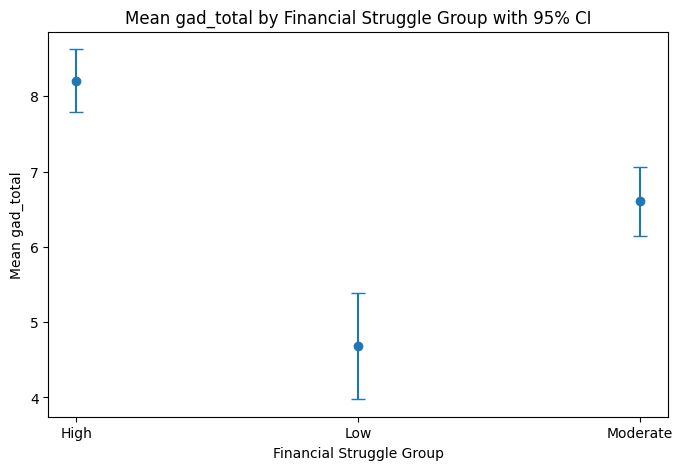

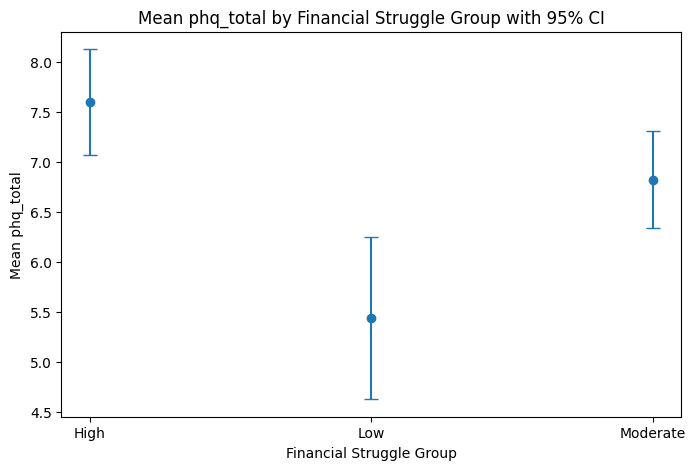

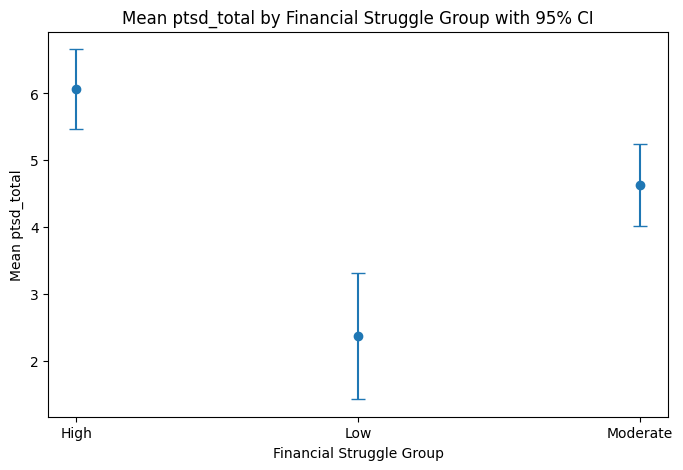

In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    summary = temp.groupby(predictor)[outcome].agg(['mean', 'count', 'std'])
    summary['se'] = summary['std'] / np.sqrt(summary['count'])
    summary['ci95'] = summary['se'] * stats.t.ppf(0.975, summary['count'] - 1)

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        x=summary.index,
        y=summary['mean'],
        yerr=summary['ci95'],
        fmt='o',
        capsize=5
    )
    plt.title(f'Mean {outcome} by Financial Struggle Group with 95% CI')
    plt.xlabel('Financial Struggle Group')
    plt.ylabel(f'Mean {outcome}')
    plt.show()

In [ ]:
score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'bill_difficulty_group'

bill_difficulty_results = []

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    # Welch ANOVA
    welch = pg.welch_anova(
        data=temp,
        dv=outcome,
        between=predictor
    )

    # Detect p-value column safely
    if 'p_unc' in welch.columns:
        p_col = 'p_unc'
    elif 'pval' in welch.columns:
        p_col = 'pval'
    elif 'p' in welch.columns:
        p_col = 'p'
    else:
        print(welch.columns)
        raise KeyError("Could not find p-value column.")

    # Kruskal-Wallis robustness check
    groups = [
        group[outcome].values
        for name, group in temp.groupby(predictor)
    ]

    h_stat, kruskal_p = stats.kruskal(*groups)

    # Group summary
    group_summary = temp.groupby(predictor)[outcome].agg(
        ['count', 'mean', 'std']
    ).reset_index()

    bill_difficulty_results.append({
        'predictor': predictor,
        'outcome': outcome,
        'n': len(temp),
        'groups': temp[predictor].nunique(),
        'welch_F': round(welch.loc[0, 'F'], 3),
        'welch_p': round(welch.loc[0, p_col], 4),
        'welch_np2': round(welch.loc[0, 'np2'], 3) if 'np2' in welch.columns else np.nan,
        'kruskal_H': round(h_stat, 3),
        'kruskal_p': round(kruskal_p, 4),
        'group_summary': group_summary[[predictor, 'count', 'mean']].to_dict('records')
    })

bill_difficulty_welch_table = pd.DataFrame(bill_difficulty_results)
bill_difficulty_welch_table

,predictor,outcome,n,groups,welch_F,welch_p,welch_np2,kruskal_H,kruskal_p,group_summary
0,bill_difficulty_group,gad_total,295,3,25.798,0.0000,0.152,43.803,0.0000,"[{'bill_difficulty_group': 'High', 'count': 10..."
1,bill_difficulty_group,phq_total,295,3,4.802,0.0092,0.031,9.633,0.0081,"[{'bill_difficulty_group': 'High', 'count': 10..."
2,bill_difficulty_group,ptsd_total,287,3,12.776,0.0000,0.079,22.084,0.0000,"[{'bill_difficulty_group': 'High', 'count': 10..."


In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    welch = pg.welch_anova(
        data=temp,
        dv=outcome,
        between=predictor
    )

    if 'p_unc' in welch.columns:
        p_col = 'p_unc'
    elif 'pval' in welch.columns:
        p_col = 'pval'
    elif 'p' in welch.columns:
        p_col = 'p'
    else:
        print(welch.columns)
        raise KeyError("Could not find p-value column.")

    p_value = welch.loc[0, p_col]

    if p_value < 0.05:
        print('\n' + '='*60)
        print(f'Games-Howell post-hoc for {outcome}')

        gh = pg.pairwise_gameshowell(
            data=temp,
            dv=outcome,
            between=predictor
        )

        print(gh.to_string()) # Changed display(gh) to print(gh.to_string()) for full output



Games-Howell post-hoc for gad_total
      A         B    mean_A    mean_B      diff        se         T          df          pval    hedges
0  High       Low  8.065421  5.550000  2.515421  0.351604  7.154136  200.869455  4.610234e-11  0.993969
1  High  Moderate  8.065421  7.193182  0.872239  0.358012  2.436339  182.456417  4.160970e-02  0.350750
2   Low  Moderate  5.550000  7.193182 -1.643182  0.376389 -4.365647  184.272693  6.246726e-05 -0.634224

Games-Howell post-hoc for phq_total
      A         B    mean_A    mean_B      diff        se         T          df      pval    hedges
0  High       Low  7.546296  6.320000  1.226296  0.399029  3.073201  204.089016  0.006774  0.425257
1  High  Moderate  7.546296  6.804598  0.741699  0.417934  1.774679  181.521494  0.181011  0.255606
2   Low  Moderate  6.320000  6.804598 -0.484598  0.428814 -1.130089  180.679006  0.496828 -0.165177

Games-Howell post-hoc for ptsd_total
      A         B    mean_A    mean_B      diff        se         T     

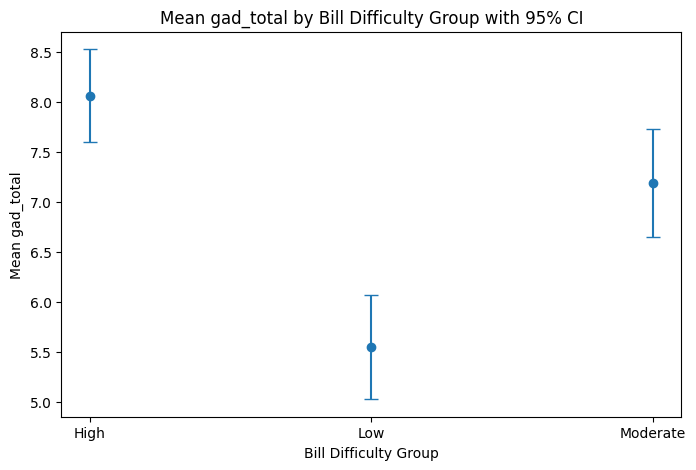

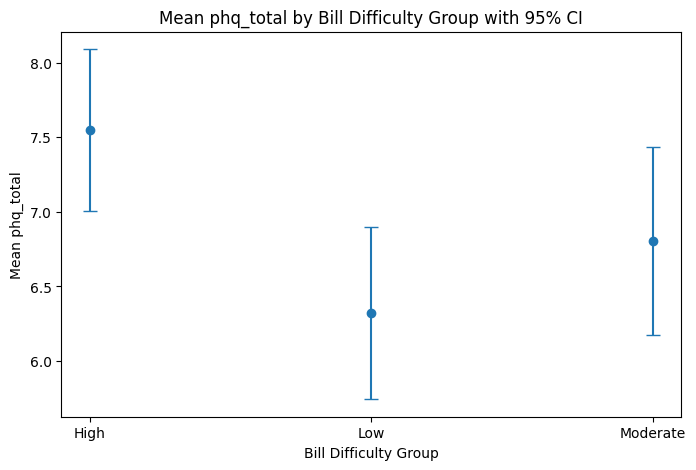

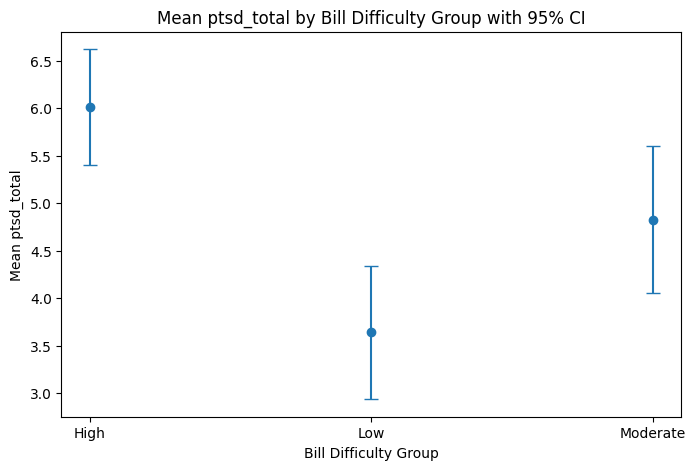

In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    summary = temp.groupby(predictor)[outcome].agg(['mean', 'count', 'std'])
    summary['se'] = summary['std'] / np.sqrt(summary['count'])
    summary['ci95'] = summary['se'] * stats.t.ppf(0.975, summary['count'] - 1)

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        x=summary.index,
        y=summary['mean'],
        yerr=summary['ci95'],
        fmt='o',
        capsize=5
    )
    plt.title(f'Mean {outcome} by Bill Difficulty Group with 95% CI')
    plt.xlabel('Bill Difficulty Group')
    plt.ylabel(f'Mean {outcome}')
    plt.show()

In [ ]:
score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'income_stability_group'

income_stability_welch_results = []

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    # Welch ANOVA
    welch = pg.welch_anova(
        data=temp,
        dv=outcome,
        between=predictor
    )

    # Kruskal-Wallis robustness check
    groups = [
        group[outcome].values
        for name, group in temp.groupby(predictor)
    ]

    h_stat, kruskal_p = stats.kruskal(*groups)

    # Group summary
    group_summary = temp.groupby(predictor)[outcome].agg(
        ['count', 'mean', 'std']
    ).reset_index()

    income_stability_welch_results.append({
        'predictor': predictor,
        'outcome': outcome,
        'n': len(temp),
        'groups': temp[predictor].nunique(),
        'welch_F': round(welch.loc[0, 'F'], 3),
        'welch_p': round(welch.loc[0, 'p_unc'], 4),
        'welch_np2': round(welch.loc[0, 'np2'], 3),
        'kruskal_H': round(h_stat, 3),
        'kruskal_p': round(kruskal_p, 4),
        'group_summary': group_summary[[predictor, 'count', 'mean']].to_dict('records')
    })

income_stability_welch_table = pd.DataFrame(income_stability_welch_results)
display(income_stability_welch_table)

,predictor,outcome,n,groups,welch_F,welch_p,welch_np2,kruskal_H,kruskal_p,group_summary
0,income_stability_group,gad_total,290,3,17.442,0.0000,0.111,29.253,0.0000,"[{'income_stability_group': 'No income', 'coun..."
1,income_stability_group,phq_total,290,3,5.831,0.0046,0.041,11.287,0.0035,"[{'income_stability_group': 'No income', 'coun..."
2,income_stability_group,ptsd_total,283,3,5.983,0.0040,0.038,10.801,0.0045,"[{'income_stability_group': 'No income', 'coun..."


In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    welch = pg.welch_anova(
        data=temp,
        dv=outcome,
        between=predictor
    )

    p_value = welch.loc[0, 'p_unc']

    if p_value < 0.05:
        print('\n' + '='*60)
        print(f'Games-Howell post-hoc for {outcome}')

        gh = pg.pairwise_gameshowell(
            data=temp,
            dv=outcome,
            between=predictor
        )

        display(gh)


Games-Howell post-hoc for gad_total


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,No income,Stable,7.482759,5.362319,2.120440,0.567524,3.736302,53.943893,1.295579e-03,0.811530
1,No income,Unstable,7.482759,7.494792,-0.012033,0.507882,-0.023693,37.262021,9.996906e-01,-0.004652
2,Stable,Unstable,5.362319,7.494792,-2.132473,0.365540,-5.833757,118.948660,1.427503e-07,-0.820835



Games-Howell post-hoc for phq_total


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,No income,Stable,7.137931,5.926471,1.211460,0.652099,1.857787,53.154364,0.161087,0.408070
1,No income,Unstable,7.137931,7.336788,-0.198857,0.582555,-0.341352,36.366970,0.937900,-0.069311
2,Stable,Unstable,5.926471,7.336788,-1.410317,0.412193,-3.421499,113.970467,0.002476,-0.489244



Games-Howell post-hoc for ptsd_total


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,No income,Stable,5.571429,3.661765,1.909664,0.791437,2.412908,46.006318,0.051034,0.561468
1,No income,Unstable,5.571429,5.213904,0.357525,0.731974,0.488439,35.076997,0.877242,0.100733
2,Stable,Unstable,3.661765,5.213904,-1.552139,0.472633,-3.284026,127.449287,0.003756,-0.447571


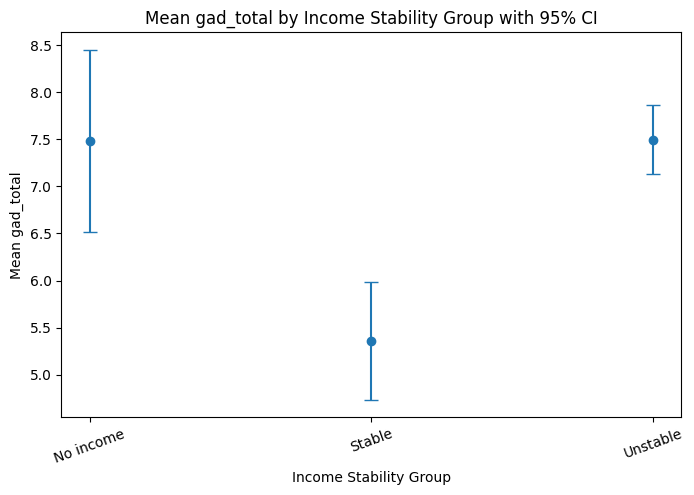

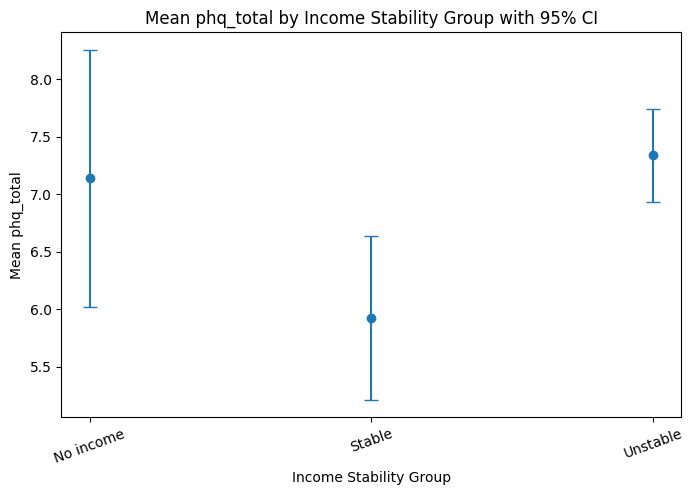

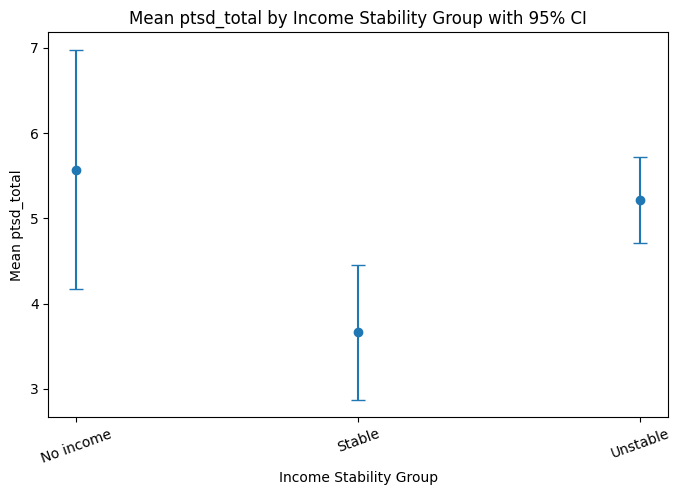

In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    summary = temp.groupby(predictor)[outcome].agg(['mean', 'count', 'std'])
    summary['se'] = summary['std'] / np.sqrt(summary['count'])
    summary['ci95'] = summary['se'] * stats.t.ppf(0.975, summary['count'] - 1)

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        x=summary.index,
        y=summary['mean'],
        yerr=summary['ci95'],
        fmt='o',
        capsize=5
    )
    plt.title(f'Mean {outcome} by Income Stability Group with 95% CI')
    plt.xlabel('Income Stability Group')
    plt.ylabel(f'Mean {outcome}')
    plt.xticks(rotation=20)
    plt.show()

In [ ]:
# Service_access GP Vs mental Health
score_outcomes = ['gad_total', 'phq_total', 'ptsd_total']
predictor = 'service_access_group'

service_access_welch_results = []

for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    # Welch ANOVA
    welch = pg.welch_anova(
        data=temp,
        dv=outcome,
        between=predictor
    )

    # Kruskal-Wallis robustness check
    groups = [
        group[outcome].values
        for name, group in temp.groupby(predictor)
    ]

    h_stat, kruskal_p = stats.kruskal(*groups)

    # Group summary
    group_summary = temp.groupby(predictor)[outcome].agg(
        ['count', 'mean', 'std']
    ).reset_index()

    service_access_welch_results.append({
        'predictor': predictor,
        'outcome': outcome,
        'n': len(temp),
        'groups': temp[predictor].nunique(),
        'welch_F': round(welch.loc[0, 'F'], 3),
        'welch_p': round(welch.loc[0, 'p_unc'], 4),
        'welch_np2': round(welch.loc[0, 'np2'], 3),
        'kruskal_H': round(h_stat, 3),
        'kruskal_p': round(kruskal_p, 4),
        'group_summary': group_summary[[predictor, 'count', 'mean']].to_dict('records')
    })

service_access_welch_table = pd.DataFrame(service_access_welch_results)
display(service_access_welch_table)

,predictor,outcome,n,groups,welch_F,welch_p,welch_np2,kruskal_H,kruskal_p,group_summary
0,service_access_group,gad_total,300,3,10.403,0.0001,0.069,18.845,0.0001,"[{'service_access_group': 'Easy', 'count': 96,..."
1,service_access_group,phq_total,300,3,4.971,0.0079,0.033,9.973,0.0068,"[{'service_access_group': 'Easy', 'count': 96,..."
2,service_access_group,ptsd_total,292,3,9.096,0.0002,0.058,16.623,0.0002,"[{'service_access_group': 'Easy', 'count': 95,..."


In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    welch = pg.welch_anova(
        data=temp,
        dv=outcome,
        between=predictor
    )

    p_value = welch.loc[0, 'p_unc']

    if p_value < 0.05:
        print('\n' + '='*60)
        print(f'Games-Howell post-hoc for {outcome}')

        gh = pg.pairwise_gameshowell(
            data=temp,
            dv=outcome,
            between=predictor
        )

        display(gh)


Games-Howell post-hoc for gad_total


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,Easy,Hard,6.020833,7.701613,-1.680780,0.369648,-4.546977,176.660510,0.000030,-0.634770
1,Easy,Moderate,6.020833,7.000000,-0.979167,0.423492,-2.312127,173.318690,0.056758,-0.344699
2,Hard,Moderate,7.701613,7.000000,0.701613,0.362415,1.935937,154.257833,0.132109,0.283738



Games-Howell post-hoc for phq_total


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,Easy,Hard,6.250,7.496000,-1.246000,0.395153,-3.153209,192.070964,0.005302,-0.432734
1,Easy,Moderate,6.250,6.949367,-0.699367,0.455007,-1.537047,168.425493,0.276275,-0.231753
2,Hard,Moderate,7.496,6.949367,0.546633,0.412015,1.326731,156.171212,0.382514,0.193443



Games-Howell post-hoc for ptsd_total


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,Easy,Hard,4.031579,5.844262,-1.812683,0.465325,-3.895523,199.048305,0.000392,-0.533264
1,Easy,Moderate,4.031579,4.240000,-0.208421,0.547860,-0.380427,155.158239,0.923370,-0.058847
2,Hard,Moderate,5.844262,4.240000,1.604262,0.516267,3.107430,146.974999,0.006376,0.463140


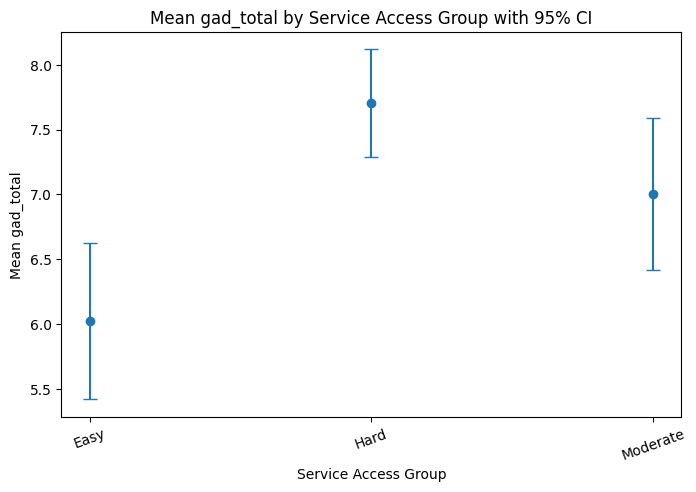

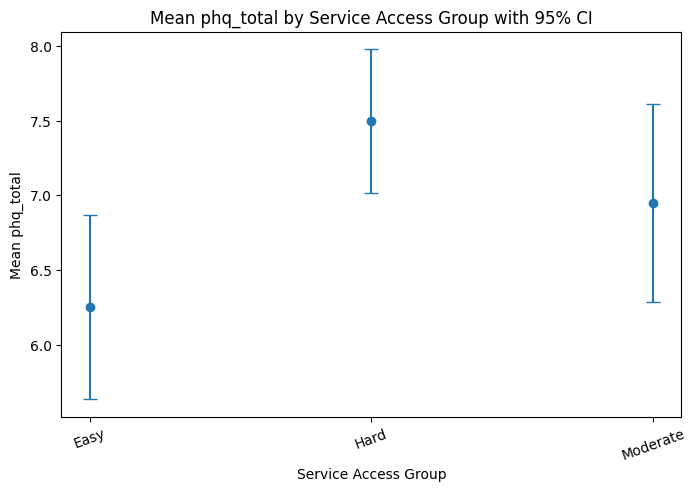

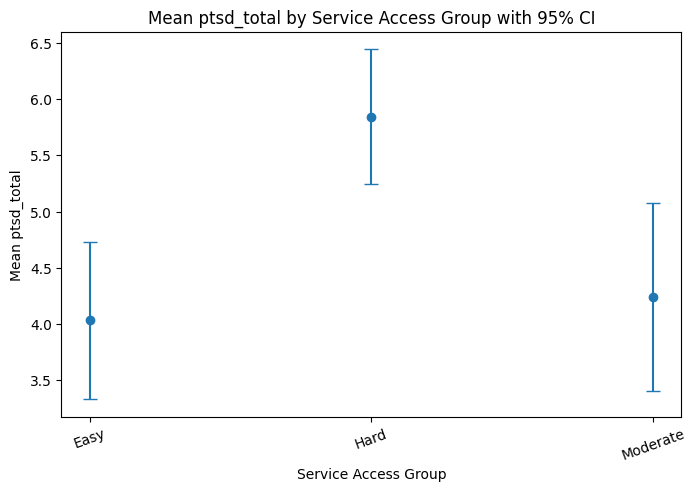

In [ ]:
for outcome in score_outcomes:
    temp = df[[outcome, predictor]].dropna()

    summary = temp.groupby(predictor)[outcome].agg(['mean', 'count', 'std'])
    summary['se'] = summary['std'] / np.sqrt(summary['count'])
    summary['ci95'] = summary['se'] * stats.t.ppf(0.975, summary['count'] - 1)

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        x=summary.index,
        y=summary['mean'],
        yerr=summary['ci95'],
        fmt='o',
        capsize=5
    )
    plt.title(f'Mean {outcome} by Service Access Group with 95% CI')
    plt.xlabel('Service Access Group')
    plt.ylabel(f'Mean {outcome}')
    plt.xticks(rotation=20)
    plt.show()

In [ ]:
anova_summary_results = []

# Employment Group (uses F-oneway and eta-squared)
for index, row in employment_anova_table.iterrows():
    anova_summary_results.append({
        'Predictor': row['predictor'],
        'Outcome': row['outcome'],
        'N': row['n'],
        'Groups': row['groups'],
        'F_statistic': row['anova_f'],
        'p_value': row['anova_p'],
        'Effect_Size_np2': row['eta_squared'],
        'Kruskal_H': row['kruskal_h'],
        'Kruskal_p': row['kruskal_p']
    })

# Other groups (use Welch ANOVA and welch_np2)
welch_tables = [
    income_welch_table,
    financial_stress_welch_table,
    financial_struggle_welch_table,
    bill_difficulty_welch_table,
    income_stability_welch_table,
    service_access_welch_table
]

for table in welch_tables:
    for index, row in table.iterrows():
        anova_summary_results.append({
            'Predictor': row['predictor'],
            'Outcome': row['outcome'],
            'N': row['n'],
            'Groups': row['groups'],
            'F_statistic': row['welch_F'],
            'p_value': row['welch_p'],
            'Effect_Size_np2': row['welch_np2'],
            'Kruskal_H': row['kruskal_H'],
            'Kruskal_p': row['kruskal_p']
        })

comparative_anova_summary = pd.DataFrame(anova_summary_results)
display(comparative_anova_summary.round(4))

,Predictor,Outcome,N,Groups,F_statistic,p_value,Effect_Size_np2,Kruskal_H,Kruskal_p
0,employment_group,gad_total,298,3,3.130,0.0452,0.021,5.312,0.0702
1,employment_group,phq_total,298,3,0.333,0.7169,0.002,0.815,0.6652
2,employment_group,ptsd_total,290,3,2.706,0.0685,0.019,5.635,0.0598
3,income_group,gad_total,298,3,23.798,0.0000,0.145,40.687,0.0000
4,income_group,phq_total,298,3,11.333,0.0000,0.075,22.646,0.0000
5,income_group,ptsd_total,290,3,24.811,0.0000,0.136,39.681,0.0000
6,financial_stress_group,gad_total,296,3,45.292,0.0000,0.247,72.401,0.0000
7,financial_stress_group,phq_total,296,3,10.658,0.0000,0.075,22.177,0.0000
8,financial_stress_group,ptsd_total,289,3,25.457,0.0000,0.151,42.368,0.0000
9,financial_struggle_group,gad_total,294,3,39.613,0.0000,0.214,61.562,0.0000


### Key Findings from ANOVA Tests:

*   **Employment Group:** Significant differences for `gad_total` (unemployed higher). No significance for `phq_total` or `ptsd_total`.
*   **Income Group:** Significant differences for all three mental health outcomes (`gad_total`, `phq_total`, `ptsd_total`). Lower income generally reported higher distress.
*   **Financial Stress Group:** Significant differences for all three mental health outcomes. Higher stress associated with higher distress.
*   **Financial Struggle Group:** Significant differences for all three mental health outcomes. Higher struggle associated with higher distress.
*   **Bill Difficulty Group:** Significant differences for all three mental health outcomes. Higher difficulty associated with higher distress.
*   **Income Stability Group:** Significant differences for all three mental health outcomes. No/unstable income associated with higher distress.
*   **Service Access Group:** Significant differences for all three mental health outcomes. Hard access associated with higher distress.

# Tests: Chi_Square

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

# Define a function to perform a single Chi-Square test
def perform_chi_square_test(df, var1, var2):
    temp_df = df[[var1, var2]].dropna()

    # Special handling for 'conflict_impact_group' to exclude 'Other' category
    if var1 == 'conflict_impact_group':
        temp_df = temp_df[temp_df[var1] != 'Other']
    if var2 == 'conflict_impact_group':
        temp_df = temp_df[temp_df[var2] != 'Other']

    table = pd.crosstab(temp_df[var1], temp_df[var2])

    # Check if table is too sparse (e.g., after removing NAs, some categories might disappear)
    if table.empty or min(table.shape) < 2:
        return {
            'var1': var1,
            'var2': var2,
            'n': len(temp_df),
            'chi2': np.nan,
            'dof': np.nan,
            'p_value': np.nan,
            'cramers_v': np.nan,
            'low_expected_cells': np.nan,
            'total_cells': np.nan,
            'expected_count_warning': 'Insufficient data or categories'
        }

    chi2, p, dof, expected = chi2_contingency(table)

    n = table.values.sum()
    min_dim = min(table.shape) - 1

    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan

    expected_df = pd.DataFrame(
        expected,
        index=table.index,
        columns=table.columns
    )

    low_expected_cells = (expected_df < 5).sum().sum()
    total_cells = expected_df.size

    return {
        'var1': var1,
        'var2': var2,
        'n': n,
        'chi2': round(chi2, 3),
        'dof': dof,
        'p_value': round(p, 4),
        'cramers_v': round(cramers_v, 3),
        'low_expected_cells': low_expected_cells,
        'total_cells': total_cells,
        'expected_count_warning': 'Yes' if low_expected_cells > 0 else 'No'
    }

# Extended list of Chi-Square tests to perform
chi_tests = [
    ('education_group', 'income_group'),
    ('employment_group', 'income_group'),
    ('income_group', 'housing_group'),
    ('income_group', 'healthcare_access_group'),
    ('living_area', 'service_access_group'),
    ('conflict_impact_group', 'housing_group'),
    ('conflict_impact_group', 'healthcare_access_group'),
    # New tests:
    ('gender_group', 'education_group'),
    ('gender_group', 'employment_group'),
    ('marital_status', 'income_group'), # Using original 'marital_status'
    ('resident_status', 'housing_group'), # Using original 'resident_status'
    ('financial_struggle_group', 'financial_stress_group'),
    ('bill_difficulty_group', 'service_access_group'),
    ('education_group', 'healthcare_access_group')
]

chi_results = []

for var1, var2 in chi_tests:
    result = perform_chi_square_test(df, var1, var2)
    chi_results.append(result)

chi_square_summary = pd.DataFrame(chi_results)
chi_square_summary

,var1,var2,n,chi2,dof,p_value,cramers_v,low_expected_cells,total_cells,expected_count_warning
0,education_group,income_group,297,10.771,2,0.0046,0.190,0,6,No
1,employment_group,income_group,297,33.289,4,0.0000,0.237,0,9,No
2,income_group,housing_group,297,23.899,2,0.0000,0.284,0,6,No
3,income_group,healthcare_access_group,294,27.165,2,0.0000,0.304,0,6,No
4,living_area,service_access_group,301,57.607,2,0.0000,0.437,0,6,No
5,conflict_impact_group,housing_group,283,22.714,1,0.0000,0.283,0,4,No
6,conflict_impact_group,healthcare_access_group,280,8.199,1,0.0042,0.171,0,4,No
7,gender_group,education_group,287,2.301,1,0.1293,0.090,0,4,No
8,gender_group,employment_group,287,0.284,2,0.8676,0.031,0,6,No
9,marital_status,income_group,288,5.588,6,0.4709,0.098,6,12,Yes


In [ ]:
for var1, var2 in chi_tests:
    temp = df[[var1, var2]].dropna()

    # Optional: remove "Other" from conflict impact if present (handled in function, but keeping for consistency if not using function)
    if var1 == 'conflict_impact_group':
        temp = temp[temp[var1] != 'Other']
    if var2 == 'conflict_impact_group':
        temp = temp[temp[var2] != 'Other']

    print('\n' + '='*70)
    print(f'{var1} x {var2}')

    count_table = pd.crosstab(temp[var1], temp[var2])
    percent_table = pd.crosstab(
        temp[var1],
        temp[var2],
        normalize='index'
    ) * 100

    print('\nCounts:')
    display(count_table)

    print('\nRow percentages:')
    display(percent_table.round(1))


education_group x income_group

Counts:


income_group,High income,Low income,Middle income
education_group,,,
High school,16,53,35
Higher education,57,65,71



Row percentages:


income_group,High income,Low income,Middle income
education_group,,,
High school,15.4,51.0,33.7
Higher education,29.5,33.7,36.8



employment_group x income_group

Counts:


...

service_access_group,Easy,Hard,Moderate
bill_difficulty_group,,,
High,15.7,68.5,15.7
Low,56.0,18.0,26.0
Moderate,23.9,35.2,40.9



education_group x healthcare_access_group

Counts:


healthcare_access_group,Has access,Limited/no access
education_group,,
High school,62,38
Higher education,160,34



Row percentages:


healthcare_access_group,Has access,Limited/no access
education_group,,
High school,62.0,38.0
Higher education,82.5,17.5


In [ ]:
new_chi_tests_to_display = [
    ('gender_group', 'education_group'),
    ('gender_group', 'employment_group'),
    ('marital_status', 'income_group'),
    ('resident_status', 'housing_group'),
    ('financial_struggle_group', 'financial_stress_group'),
    ('bill_difficulty_group', 'service_access_group'),
    ('education_group', 'healthcare_access_group')
]

for var1, var2 in new_chi_tests_to_display:
    temp = df[[var1, var2]].dropna()

    # Special handling for 'conflict_impact_group' is not strictly needed here
    # as these are new pairs not involving conflict_impact_group in var1, but kept
    # for consistency if the list were to be modified.
    if var1 == 'conflict_impact_group':
        temp = temp[temp[var1] != 'Other']
    if var2 == 'conflict_impact_group':
        temp = temp[temp[var2] != 'Other']

    print('\n' + '='*70)
    print(f'{var1} x {var2}')

    count_table = pd.crosstab(temp[var1], temp[var2])
    percent_table = pd.crosstab(
        temp[var1],
        temp[var2],
        normalize='index'
    ) * 100

    print('\nCounts:')
    display(count_table)

    print('\nRow percentages:')
    display(percent_table.round(1))

# Note: The chi_square_summary DataFrame already contains results for these new tests.


gender_group x education_group

Counts:


education_group,High school,Higher education
gender_group,,
Female,41,97
Male,58,91



Row percentages:


education_group,High school,Higher education
gender_group,,
Female,29.7,70.3
Male,38.9,61.1



gender_group x employment_group

Counts:


...

service_access_group,Easy,Hard,Moderate
bill_difficulty_group,,,
High,15.7,68.5,15.7
Low,56.0,18.0,26.0
Moderate,23.9,35.2,40.9



education_group x healthcare_access_group

Counts:


healthcare_access_group,Has access,Limited/no access
education_group,,
High school,62,38
Higher education,160,34



Row percentages:


healthcare_access_group,Has access,Limited/no access
education_group,,
High school,62.0,38.0
Higher education,82.5,17.5


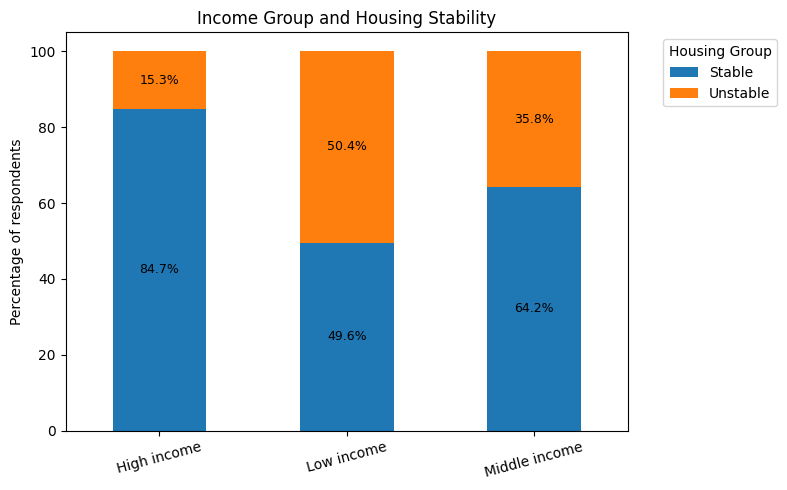

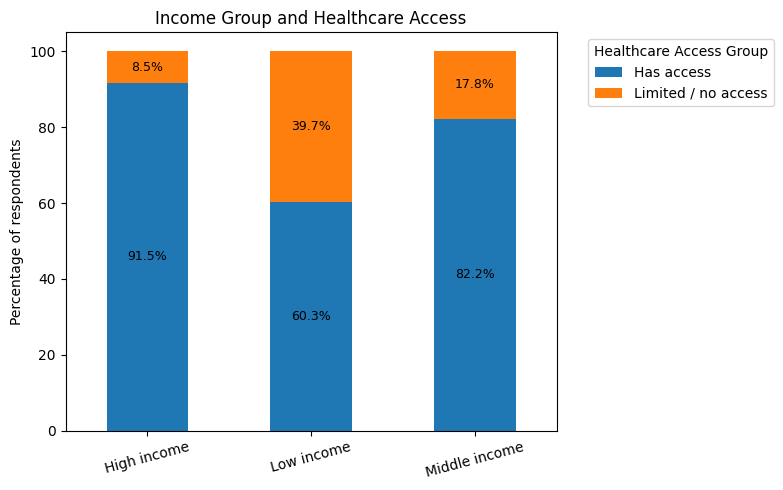

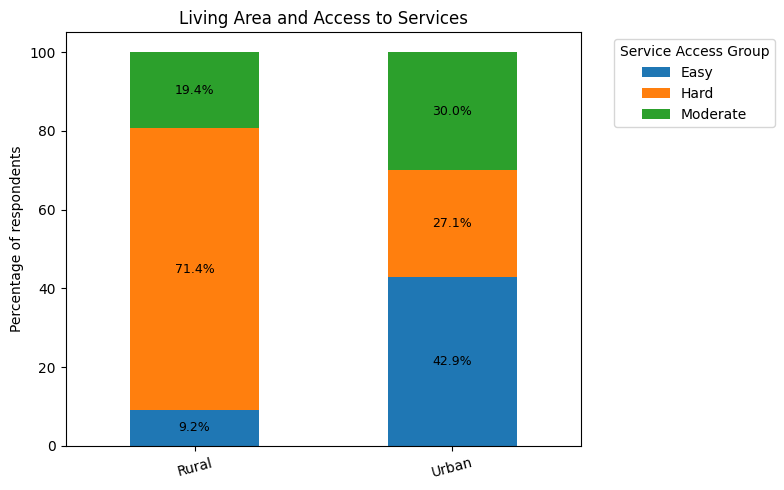

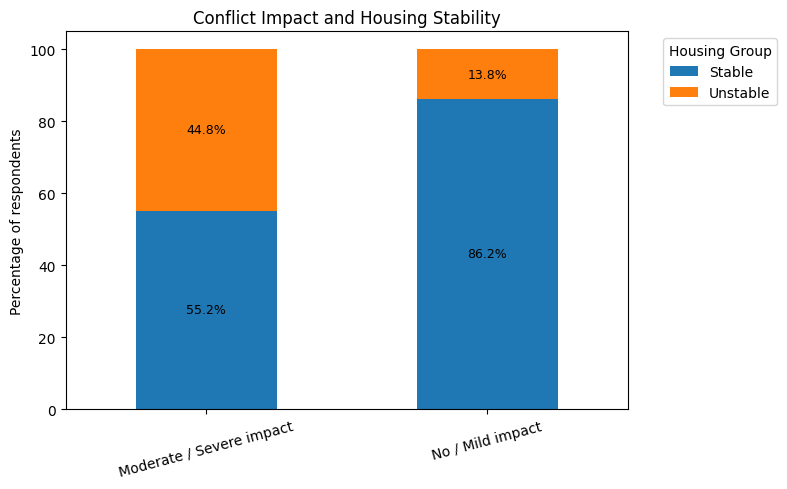

In [ ]:
import matplotlib.pyplot as plt

# Selected chi-square associations for final report
chi_report_tests = [
    ('income_group', 'housing_group', 'Income Group and Housing Stability'),
    ('income_group', 'healthcare_access_group', 'Income Group and Healthcare Access'),
    ('living_area', 'service_access_group', 'Living Area and Access to Services'),
    ('conflict_impact_group', 'housing_group', 'Conflict Impact and Housing Stability')
]

# Clean display labels without changing original dataframe
label_replacements = {
    'Stable housing': 'Stable',
    'Unstable housing': 'Unstable',
    'Has access': 'Has access',
    'Limited/no access': 'Limited / no access',
    'Rural (villages, countryside)': 'Rural',
    'Urban ( City, Town)': 'Urban',
    'No/Mild Impact': 'No / Mild impact',
    'Moderate/Severe Impact': 'Moderate / Severe impact'
}

for var1, var2, plot_title in chi_report_tests:
    temp = df[[var1, var2]].dropna().copy()

    # Remove "Other" category from conflict impact if present
    if var1 == 'conflict_impact_group':
        temp = temp[temp[var1] != 'Other']
    if var2 == 'conflict_impact_group':
        temp = temp[temp[var2] != 'Other']

    # Apply clean labels only for plotting
    temp[var1] = temp[var1].replace(label_replacements)
    temp[var2] = temp[var2].replace(label_replacements)

    # Create row percentage table
    percent_table = pd.crosstab(
        temp[var1],
        temp[var2],
        normalize='index'
    ) * 100

    # Plot 100% stacked bar chart
    ax = percent_table.plot(
        kind='bar',
        stacked=True,
        figsize=(8, 5)
    )

    plt.title(plot_title)
    plt.xlabel('')
    plt.ylabel('Percentage of respondents')
    plt.xticks(rotation=15)
    plt.legend(
        title=var2.replace('_', ' ').title(),
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

    # Add percentage labels inside bars
    for container in ax.containers:
        labels = [
            f'{value:.1f}%' if value >= 5 else ''
            for value in container.datavalues
        ]
        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

##Key Findings from Chi_Square Tests

 * Income Group and Housing Stability (Cramér's V = 0.284): This plot illustrates a moderate association between income group and housing stability. Individuals in lower income groups tend to report higher percentages of unstable housing situations, while those in higher income groups show a greater proportion of stable housing. For example, a larger percentage of 'Low income' respondents reported 'Unstable' housing compared to 'High income' respondents.

* Income Group and Healthcare Access (Cramér's V = 0.304): This plot shows a moderate association, indicating that healthcare access varies across income groups. A higher proportion of individuals in 'Limited / no access' healthcare groups are found within the 'Low income' category, whereas 'Has access' is more prevalent in 'High income' groups.

* Living Area and Access to Services (Cramér's V = 0.437): This plot reveals a strong association. Respondents from 'Rural' areas disproportionately report 'Hard' access to services, while those in 'Urban' areas generally experience 'Easy' or 'Moderate' access. The differences in access levels are quite pronounced between rural and urban living areas.

* Conflict Impact and Housing Stability (Cramér's V = 0.283): This plot indicates a moderate association. Individuals who experienced 'Moderate / Severe impact' from conflict show a higher percentage of 'Unstable' housing compared to those with 'No / Mild impact', who predominantly report 'Stable' housing. This suggests that the severity of conflict impact is linked to housing stability.